# Solenoid Design-Space Study — Main Driver

Sweeps a set of solenoid lengths, builds the winding-thickness design grid for
each, and writes one long-format CSV per length for downstream plotting.

**Pipeline**

`config` → `solenoid_lib` (physics) → `grid` (mesh sweep) → `io_grids` (CSV out)
→ `plots_thickness` / `plots_area` (figures)

**Outputs:** `thickness_grids_L<length>mm.csv`, one row per (thickness, radius)
grid node, with fields `ri`, `th`, `v`, `v_bore`, `b0`, `scan`, `length_tape_km`,
`pancake_length_m` and the associated current-density and stress diagnostics.
Files are written to the kernel's working directory — in VS Code this is set by
`jupyter.notebookFileRoot` and is not necessarily this file's folder, so check
`Path.cwd()` if the analysis notebook can't find them.

**Run as a notebook or in the VS Code interactive window** — `%matplotlib widget`
is a cell magic and will not parse under `python main.py`. Interactive picking in
the plotting modules needs `ipympl` installed in the kernel's environment; if
figures come up blank, re-run the cell or switch to `%matplotlib qt`.

Modules are hot-reloaded dependency-first on every execution, so editing a
library file and re-running this cell is enough; no kernel restart needed.

> **Note:** re-running this cell rebuilds `all_grids` and rewrites the CSVs.
> Any downstream cell holding an older `df_all` must be re-run too, or it will
> silently plot stale data.

In [ ]:
# # main.py
# # ─────────────────────────────────────────────────────────────────────────────
# # Orchestrates the full solenoid design-space study.
# #
# #   Run in Jupyter/IPython to utilize interactive widgets.
# # ─────────────────────────────────────────────────────────────────────────────
# %matplotlib widget

# import importlib

# # Hot-reload local modules, dependency-first, so a reloaded module never holds
# # references to a stale version of something below it.
# import config
# importlib.reload(config)

# import solenoid_lib
# importlib.reload(solenoid_lib)

# import grid
# importlib.reload(grid)

# import io_grids
# importlib.reload(io_grids)

# import plots_thickness
# importlib.reload(plots_thickness)

# import plots_area
# importlib.reload(plots_area)


# # Define the lengths (in meters) to iterate over
# LENGTHS_M = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]  # meters


# def main():
#     all_grids = {}

#     for L in LENGTHS_M:
#         print(f"\n=== Solenoid Length = {L*1e3:.0f} mm ===")

#         # 1. Update the physics library with the current length
#         solenoid_lib.solenoid_length = L
#         label = f"L{int(round(L*1e3))}mm"

#         # 2. Build the meshgrids based on Thickness
#         a_grids = grid.build_thickness_grid()

#         # 3. Save the results to the newly formatted CSV
#         csv_filename = f"thickness_grids_{label}.csv"
#         io_grids.save_grids_long(a_grids, csv_filename, solenoid_length=L)

#         # 4. Generate all the requested contour plots
#         #plots_thickness.plot_all(a_grids, label=label, solenoid_length_m=L)

#         # Store for return
#         all_grids[L] = a_grids

#     return all_grids


# if __name__ == "__main__":
#     # Run the main loop
#     all_grids = main()








# main.py

%matplotlib widget

import importlib

import numpy as np

# Hot-reload local modules, dependency-first, so a reloaded module never holds
# references to a stale version of something below it.
import config
importlib.reload(config)

import solenoid_lib
importlib.reload(solenoid_lib)

import grid
importlib.reload(grid)

print(grid.__file__)
print(hasattr(grid, "RESULT_KEYS"))
print(hasattr(solenoid_lib, "solve_design"), hasattr(solenoid_lib, "DesignParams"))

import io_grids
importlib.reload(io_grids)

import plots_thickness
importlib.reload(plots_thickness)

import plots_area
importlib.reload(plots_area)


# Define the lengths (in meters) to iterate over
LENGTHS_M = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]  # meters


def main():
    all_grids = {}

    for L in LENGTHS_M:
        print(f"\n=== Solenoid Length = {L*1e3:.0f} mm ===")

        # 1. Update the physics library with the current length.
        solenoid_lib.solenoid_length = L
        config.L_COIL = L
        label = f"L{int(round(L*1e3))}mm"

        # 2. Build the meshgrids based on Thickness
        a_grids = grid.build_thickness_grid()

        # 3. Save the results to the newly formatted CSV.
        csv_filename = f"thickness_grids_{label}.csv"
        io_grids.save_grids_long(a_grids, csv_filename)

        # 4. What the quench protection costs on this map
        b0, b0m = a_grids["b0"], a_grids["b0_mech"]
        ok = np.isfinite(b0)
        if np.any(ok):
            print(f"  quench cost: median "
                  f"{100*np.nanmedian(1 - b0[ok]/b0m[ok]):.1f} % of B0, "
                  f"{np.count_nonzero(~ok & a_grids['valid'])} cells unprotectable")

        # 5. Generate all the requested contour plots
        #plots_thickness.plot_all(a_grids, label=label, solenoid_length_m=L)

        # Store for return
        all_grids[L] = a_grids

    return all_grids


if __name__ == "__main__":
    # Run the main loop
    all_grids = main()


=== Solenoid Length = 2000 mm ===
Th-scan axes:
  Ri          : 100 pts, 1.000 – 1500.000 mm, step 15.141 → 15.141 mm (coarsening) (uniform would be 15.141)
  Th          : 100 pts, 2.000 – 500.000 mm, step 0.051 → 10.010 mm (coarsening) (uniform would be 5.030)
  10000/10000  (100%)
2-D meshgrid (Th-scan) computed.
  Valid cells     : 10000 / 10000
  Converged cells : 10000 / 10000
  Ri              : 1.0 – 1500.0 mm
  Th (mm)         : 2.00 – 500.00
  f_tape_min (%)  : 2.94 – 99.89
  Len tape (km)   : 0.03 – 539.16
  B0              : 1.012 – 36.416 T
  Stress          : 3.4 – 750.0 MPa
Saved raw grids    -> thickness_grids_L2000mm.csv  (10000 cells, 10000 feasible, 20 columns)

=== Solenoid Length = 3000 mm ===
Th-scan axes:
  Ri          : 100 pts, 1.000 – 1500.000 mm, step 15.141 → 15.141 mm (coarsening) (uniform would be 15.141)
  Th          : 100 pts, 2.000 – 500.000 mm, step 0.051 → 10.010 mm (coarsening) (uniform would be 5.030)
  10000/10000  (100%)
2-D meshgrid (Th-scan) c

# Detailed Parameter Maps — Contour Analysis per Solenoid Length

Loads every `thickness_grids_L*.csv` in the working directory and draws a
three-panel map of the design space for one selected solenoid length.

All panels share `Ri` (mm) on the x-axis and a filled scan-time background,
differing only in the y-quantity: coil thickness (mm), tape length per pancake
(m), and total tape length (km). Iso-lines: **B₀** (black), **scan time** (blue,
dashed), **hoop stress** (crimson, dash-dot), plus **thickness** (purple,
dotted) on panels 2 and 3. Grid nodes are drawn invisibly as pick targets —
click one for a tooltip with its full parameter set.

Values are interpolated onto a 400×400 mesh with `griddata`; blank regions are
outside the convex hull of the data, not physically excluded. Legacy `*_sc`
column names are remapped per-file before the concat and flagged with `[!]`.

Set `selected_length` in the last section to any value present in
`solenoid_length_m` (exact match required).

> Axis limits are hard-coded (0–1500 mm; 400 mm / 2500 m / 3000 km) and the
> scan-time fill is clipped at 20 yr — designs outside are silently off-screen.
> Tooltips need `%matplotlib widget` and a live kernel.

In [ ]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
import glob

# -------------------------------------------------------------------------
# 1. LOAD DATA
#    Legacy "sc" column names are remapped per-file, before the concat, so
#    that a mix of old and new CSVs lines up on the same columns instead of
#    producing two half-NaN columns.
# -------------------------------------------------------------------------
_LEGACY_RENAMES = {
    "f_sc": "f_tape_min",
    "length_sc": "length_tape",
    "je_sc": "je_tape",
    "a_sc": "a_tape",
    "rebco_pancake_length": "tape_pancake_length",
    "length_tape_km": "length_tape_km",   # derived col, written by io_grids
}

def _read_grid_csv(path):
    df = pd.read_csv(path)
    hits = {k: v for k, v in _LEGACY_RENAMES.items() if k in df.columns}
    if hits:
        pairs = ", ".join(f"{k}->{v}" for k, v in hits.items())
        print(f"[!] {path}: legacy columns remapped ({pairs})")
        df = df.rename(columns=hits)
    return df

file_list = sorted(glob.glob('thickness_grids_L*.csv'))
if not file_list:
    raise FileNotFoundError("No thickness_grids_L*.csv found in the working directory.")
df_all = pd.concat((_read_grid_csv(f) for f in file_list), ignore_index=True)

# -------------------------------------------------------------------------
# 2. HELPER FUNCTIONS (Interactivity & Regridding)
# -------------------------------------------------------------------------
def setup_grid_annotation(fig, scatters, data_dfs, active_axes):
    annots = []
    for ax in active_axes:
        annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=8, zorder=10)
        annot.set_visible(False)
        annots.append(annot)

    def on_pick(event):
        # Hide all annotations first
        for ann in annots:
            ann.set_visible(False)

        # Find which scatter point was clicked/hovered
        for i, scat in enumerate(scatters):
            if event.artist == scat:
                ind = event.ind[0]
                row = data_dfs[i].iloc[ind]
                x, y = event.artist.get_offsets()[ind]

                text = (f"L={row['solenoid_length_m']:.1f} m\n"
                        f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                        f"B0={row['b0']:.2f} T\n"
                        f"Total tape={row['length_tape_km']:.1f} km\n"
                        f"Pancake={row['pancake_length_m']:.1f} m\n"
                        f"Scan={row['scan']:.1f} yrs")

                annots[i].xy = (x, y)
                annots[i].set_text(text)
                annots[i].set_visible(True)
                fig.canvas.draw_idle()
                break

    fig.canvas.mpl_connect("pick_event", on_pick)


def _regrid(x, y, z, nx=400, ny=400):
    xf, yf, zf = np.asarray(x).flatten(), np.asarray(y).flatten(), np.asarray(z).flatten()
    mask = np.isfinite(xf) & np.isfinite(yf) & np.isfinite(zf)

    if not mask.any():
        xi = np.linspace(np.nanmin(xf) if len(xf) else 0, np.nanmax(xf) if len(xf) else 1, nx)
        yi = np.linspace(np.nanmin(yf) if len(yf) else 0, np.nanmax(yf) if len(yf) else 1, ny)
        xi2d, yi2d = np.meshgrid(xi, yi)
        return xi2d, yi2d, np.full_like(xi2d, np.nan)

    xi = np.linspace(np.nanmin(xf[mask]), np.nanmax(xf[mask]), nx)
    yi = np.linspace(np.nanmin(yf[mask]), np.nanmax(yf[mask]), ny)
    xi2d, yi2d = np.meshgrid(xi, yi)
    zi2d = griddata((xf[mask], yf[mask]), zf[mask], (xi2d, yi2d), method="linear")
    return xi2d, yi2d, zi2d


def draw_contours(ax, x, y, df, plot_type):
    scan_limit = 20.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

    field_line_levels = [5, 10, 15, 25, 30, 40, 50, 55, 60]

    th_line_levels = [50, 100, 150, 200, 250, 300, 350, 400]

    # 1. Scan time background map
    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)

    # 2. Magnetic Field (B0)
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.5, levels=field_line_levels, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0f T', fontsize=8, colors='black')

    # 3. Scan Time (Lines)
    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.2, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0f yr', fontsize=8, colors='steelblue')

    # 4. Hoop Stress
    stress_levels = 10 if plot_type == 3 else 3
    _, _, zi_stress = _regrid(x, y, df['stress'])
    if np.isfinite(zi_stress).any():
        iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.2, levels=stress_levels, zorder=3)
        ax.clabel(iso_stress, inline=True, fmt='%.0f MPa', fontsize=8, colors='crimson')

    # 5. Thickness (Only for Graphs 2 and 3)
    if plot_type in [2, 3]:
        _, _, zi_th = _regrid(x, y, df['th'] * 1000)
        if np.isfinite(zi_th).any():
            iso_th = ax.contour(xi, yi, zi_th, colors='purple', linestyles='dotted', linewidths=1.2, levels=th_line_levels, zorder=3)
            ax.clabel(iso_th, inline=True, fmt='%.0f mm', fontsize=8, colors='purple')

    return cntr

# -------------------------------------------------------------------------
# 3. MAIN PLOTTING FUNCTION
# -------------------------------------------------------------------------
def plot_selected_length(target_length_m, df_full):
    # Filter the DataFrame for the selected length
    df_sub = df_full[df_full['solenoid_length_m'] == target_length_m].reset_index(drop=True)

    if df_sub.empty:
        print(f"No data found for L = {target_length_m} m.")
        print(f"Available lengths are: {sorted(df_full['solenoid_length_m'].unique())}")
        return

    # Create the 1x3 figure
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
    fig.suptitle(f'Detailed Parameter Maps for Solenoid Length L = {target_length_m*1000:.0f} mm', fontsize=16, fontweight='bold', y=1)

    x_mm = df_sub['ri'] * 1000
    scats = []

    # Legend Elements
    leg1 = [
        Line2D([0], [0], color='black', lw=1.5, label='B₀ (T)'),
        Line2D([0], [0], color='steelblue', lw=1.5, linestyle='--', label='Scan time (yr)'),
        Line2D([0], [0], color='crimson', lw=1.5, linestyle='-.', label='Hoop stress (MPa)')
    ]
    leg23 = leg1 + [Line2D([0], [0], color='purple', lw=1.5, linestyle=':', label='Thickness (mm)')]

    # Graph 1: Coil Thickness
    ax1 = axes[0]
    y1_mm = df_sub['th'] * 1000
    cntr1 = draw_contours(ax1, x_mm, y1_mm, df_sub, plot_type=1)
    fig.colorbar(cntr1, ax=ax1, label='Scan time (yr)')

    ax1.set_xlabel('Inner radius Ri (mm)')
    ax1.set_ylabel('Coil thickness (mm)')
    ax1.set_title('1. Coil Thickness vs Inner Radius')
    ax1.legend(handles=leg1, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax1.scatter(x_mm, y1_mm, color='white', alpha=0.0, picker=5, zorder=5))
    ax1.set_xlim(0, 3000)  # Set x-axis limit to 1500 mm
    ax1.set_ylim(0, 500)   # Set y-axis limit to 500 mm

    # Graph 2: Pancake Length
    ax2 = axes[1]
    y2_m = df_sub['pancake_length_m']
    cntr2 = draw_contours(ax2, x_mm, y2_m, df_sub, plot_type=2)
    fig.colorbar(cntr2, ax=ax2, label='Scan time (yr)')

    ax2.set_xlabel('Inner radius Ri (mm)')
    ax2.set_ylabel('Tape length per pancake (m)')
    ax2.set_title('2. Pancake Length vs Inner Radius')
    ax2.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax2.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax2.scatter(x_mm, y2_m, color='white', alpha=0.0, picker=5, zorder=5))
    ax2.set_xlim(0, 3000)  # Set x-axis limit to 1500 mm
    ax2.set_ylim(0, 700)  # Set y-axis limit to 700 m


    # Graph 3: Total Tape Length
    ax3 = axes[2]
    y3_km = df_sub['length_tape_km']
    cntr3 = draw_contours(ax3, x_mm, y3_km, df_sub, plot_type=3)
    fig.colorbar(cntr3, ax=ax3, label='Scan time (yr)')

    ax3.set_xlabel('Inner radius Ri (mm)')
    ax3.set_ylabel('Total tape length (km)')
    ax3.set_title('3. Total Tape Length vs Inner Radius')
    ax3.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax3.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax3.scatter(x_mm, y3_km, color='white', alpha=0.0, picker=5, zorder=5))
    ax3.set_xlim(0, 3000)  # Set x-axis limit to 1500 mm
    ax3.set_ylim(0, 700)  # Set y-axis limit to 700 km

    # Connect interactivity and adjust layout
    setup_grid_annotation(fig, scats, [df_sub, df_sub, df_sub], axes)
    fig.tight_layout()
    plt.show()

# -------------------------------------------------------------------------
# 4. EXECUTE PLOT
# Change the length below to map a different target length (e.g. 5.0, 6.0)
# -------------------------------------------------------------------------
selected_length = 7.0
plot_selected_length(selected_length, df_all)

# Parameter Maps — Contour Grids across Solenoid Lengths

Loads every `thickness_grids_L*.csv` in the working directory and draws three
2×5 figures, one panel per value of `solenoid_length_m` (first ten only; any
further lengths are silently dropped by the `if i >= 10: break` guard).

All panels share `Ri` (mm) on the x-axis and a filled scan-time background,
differing only in the y-quantity: **Fig. 1** coil thickness (mm), **Fig. 2**
tape length per pancake (m), **Fig. 3** total tape length (km). Iso-lines:
**B₀** (black), **scan time** (blue, dashed), **hoop stress** (crimson,
dash-dot), plus **thickness** (purple, dotted) on Figs. 2 and 3. Grid nodes are
drawn invisibly as pick targets — click one for a tooltip with its full
parameter set.

Values are interpolated onto a 400×400 mesh with `griddata`; blank regions are
outside the convex hull of that panel's data, not physically excluded. Each
panel regrids over its own x/y extent, so meshes are not aligned between
panels. Figures 2 and 3 use `sharey=True` with explicit limits (0–3000 m and
0–1500 km); Figure 1's axes are left to autoscale, so its y-range varies panel
to panel.

> The scan-time fill is clipped to 1–20 yr on a fixed 25-level scale, so the
> colour mapping is comparable across every panel and figure — designs outside
> that window show as blank background.
>
> B₀ and stress iso-lines use automatic level selection, so their values differ
> between panels; pin them to explicit level lists before comparing panels.
>
> No `*_sc` legacy column remapping is performed in this version — all input
> files must already use `ri`, `th`, `b0`, `stress`, `scan`,
> `pancake_length_m`, `length_tape_km`, `solenoid_length_m`.
>
> Tooltips need `%matplotlib widget` and a live kernel.

In [ ]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
import glob

# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)

# -------------------------------------------------------------------------
# 2. HELPER FUNCTIONS
# -------------------------------------------------------------------------
def setup_grid_annotation(fig, scatters, data_dfs, active_axes):
    annots = []
    for ax in active_axes:
        annot = ax.annotate("", xy=(0, 0), xytext=(10, 10), textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=7, zorder=10)
        annot.set_visible(False)
        annots.append(annot)

    def on_pick(event):
        for ann in annots:
            ann.set_visible(False)
            
        for i, scat in enumerate(scatters):
            if event.artist == scat:
                ind = event.ind[0]
                row = data_dfs[i].iloc[ind]
                x, y = event.artist.get_offsets()[ind]
                
                text = (f"L={row['solenoid_length_m']:.1f} m\n"
                        f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                        f"B0={row['b0']:.2f} T\n"
                        f"Total SC={row['length_tape_km']:.1f} km\n"
                        f"Pancake={row['pancake_length_m']:.1f} m\n"
                        f"Scan={row['scan']:.1f} yrs")
                
                annots[i].xy = (x, y)
                annots[i].set_text(text)
                annots[i].set_visible(True)
                fig.canvas.draw_idle()
                break

    fig.canvas.mpl_connect("pick_event", on_pick)


def _regrid(x, y, z, nx=400, ny=400):
    xf, yf, zf = np.asarray(x).flatten(), np.asarray(y).flatten(), np.asarray(z).flatten()
    mask = np.isfinite(xf) & np.isfinite(yf) & np.isfinite(zf)
    
    if not mask.any():
        xi = np.linspace(np.nanmin(xf) if len(xf) else 0, np.nanmax(xf) if len(xf) else 1, nx)
        yi = np.linspace(np.nanmin(yf) if len(yf) else 0, np.nanmax(yf) if len(yf) else 1, ny)
        xi2d, yi2d = np.meshgrid(xi, yi)
        return xi2d, yi2d, np.full_like(xi2d, np.nan)
        
    xi = np.linspace(np.nanmin(xf[mask]), np.nanmax(xf[mask]), nx)
    yi = np.linspace(np.nanmin(yf[mask]), np.nanmax(yf[mask]), ny)
    xi2d, yi2d = np.meshgrid(xi, yi)
    zi2d = griddata((xf[mask], yf[mask]), zf[mask], (xi2d, yi2d), method="linear")
    return xi2d, yi2d, zi2d


def draw_contours_small(ax, x, y, df):
    scan_limit = 20.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 

    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)
    
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.0, levels=10, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0fT', fontsize=6, colors='black')

    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.0, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0fyr', fontsize=6, colors='steelblue')

    # _, _, zi_stress = _regrid(x, y, df['stress'])
    # if np.isfinite(zi_stress).any():
    #     iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.0, levels=3, zorder=3)
    #     ax.clabel(iso_stress, inline=True, fmt='%.0fMPa', fontsize=6, colors='crimson')
            
    return cntr


def draw_contours_small_2_3(ax, x, y, df, plot_type):
    scan_limit = 20.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 

    field_line_levels = [5, 10 ,15, 25, 30, 40, 50, 55, 60] 

    th_line_levels = [50, 100, 150, 200, 250, 300, 350, 400]

    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)
    
    # B0
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.0, levels=field_line_levels, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0fT', fontsize=6, colors='black')

    # Scan Time
    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.0, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0fyr', fontsize=6, colors='steelblue')

    # # Hoop Stress (Graph 3 often needs more levels to show detail)
    # stress_levels = 10 if plot_type == 3 else 3
    # _, _, zi_stress = _regrid(x, y, df['stress'])
    # if np.isfinite(zi_stress).any():
    #     iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.0, levels=stress_levels, zorder=3)
    #     ax.clabel(iso_stress, inline=True, fmt='%.0fMPa', fontsize=6, colors='crimson')

    # Thickness Lines (Purple dotted)
    _, _, zi_th = _regrid(x, y, df['th'] * 1000)
    if np.isfinite(zi_th).any():
        iso_th = ax.contour(xi, yi, zi_th, colors='purple', linestyles='dotted', linewidths=1.0, levels=th_line_levels, zorder=3)
        ax.clabel(iso_th, inline=True, fmt='%.0fmm', fontsize=6, colors='purple')
            
    return cntr

# Legend for Graphs 2 and 3
leg23_elements = [
    Line2D([0], [0], color='black', lw=1.2, label='B₀'),
    Line2D([0], [0], color='steelblue', lw=1.2, linestyle='--', label='Scan'),
    Line2D([0], [0], color='crimson', lw=1.2, linestyle='-.', label='Stress'),
    Line2D([0], [0], color='purple', lw=1.2, linestyle=':', label='Thickness') 
]

unique_lengths = sorted(df_all['solenoid_length_m'].unique())



# -------------------------------------------------------------------------
# 3. SET UP GRID AND PLOT
# -------------------------------------------------------------------------
unique_lengths = sorted(df_all['solenoid_length_m'].unique())

# Smaller figure size
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False)
fig.suptitle('Coil Thickness vs Inner Radius', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
scats = []
dfs = []
active_axes = []

# Compact legend elements
leg1_elements = [
    Line2D([0], [0], color='black', lw=1.2, label='B₀'),
    Line2D([0], [0], color='steelblue', lw=1.2, linestyle='--', label='Scan'),
    Line2D([0], [0], color='crimson', lw=1.2, linestyle='-.', label='Stress'),
    Line2D([0], [0], color='purple', lw=1.2, linestyle=':', label='SC Len') 
]

for i, L in enumerate(unique_lengths):
    if i >= 10:
        break
        
    df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
    ax = axes_flat[i]
    
    x_mm = df_sub['ri'] * 1000
    y1_mm = df_sub['th'] * 1000
    
    cntr = draw_contours_small(ax, x_mm, y1_mm, df_sub)
    
    # Add a thin colorbar with smaller font
    cbar = fig.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)
    if i % 5 == 4: # Only label the colorbars on the far right to save space
        cbar.set_label('Scan time (yr)', size=8)
    
    if i >= 5: # Only label x-axis on bottom row
        ax.set_xlabel('Ri (mm)', fontsize=8)
    if i % 5 == 0:
        ax.set_ylabel('Coil th (mm)', fontsize=8)
        
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
    ax.legend(handles=leg1_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
    #scat = ax.scatter(x_mm, y1_mm, color='white', alpha=0.0, picker=5, zorder=5)

    ax.set_xlim(0, 3000)    
    ax.set_ylim(0, 500)     
    
    #scats.append(scat)
    dfs.append(df_sub)
    active_axes.append(ax)

# Hide any blank subplots
for j in range(len(active_axes), len(axes_flat)):
    axes_flat[j].set_visible(False)

setup_grid_annotation(fig, scats, dfs, active_axes)


fig.tight_layout()
plt.show()



# # =========================================================================
# # FIGURE 2: PANCAKE LENGTH VS INNER RADIUS (Shared Y-Axis)
# # =========================================================================
# # Find global min and max for pancake length to set consistent limits
# y2_min, y2_max = df_all['pancake_length_m'].min(), 3000

# # Add sharey=True here
# fig2, axes2 = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False, sharey=True)
# fig2.suptitle('2. Pancake Length vs Inner Radius', fontsize=14, fontweight='bold')

# axes2_flat = axes2.flatten()
# scats2, dfs2, active_axes2 = [], [], []

# for i, L in enumerate(unique_lengths):
#     if i >= 10: break
#     df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
#     ax = axes2_flat[i]
#     x_mm = df_sub['ri'] * 1000
#     y2_m = df_sub['pancake_length_m']
    
#     cntr = draw_contours_small_2_3(ax, x_mm, y2_m, df_sub, plot_type=2)
    
#     cbar = fig2.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=7)
#     if i % 5 == 4: cbar.set_label('Scan time (yr)', size=8)
    
#     if i >= 5: ax.set_xlabel('Ri (mm)', fontsize=8)
#     if i % 5 == 0: ax.set_ylabel('Pancake len (m)', fontsize=8)
        
#     ax.tick_params(axis='both', which='major', labelsize=7)
#     ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
#     # Set the shared limits explicitly
#     ax.set_ylim(y2_min - y2_pad, y2_max + y2_pad)
    
#     ax.legend(handles=leg23_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
#     ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
#     scat = ax.scatter(x_mm, y2_m, color='white', alpha=0.0, picker=5, zorder=5)
#     scats2.append(scat); dfs2.append(df_sub); active_axes2.append(ax)

# for j in range(len(active_axes2), len(axes2_flat)): axes2_flat[j].set_visible(False)
# setup_grid_annotation(fig2, scats2, dfs2, active_axes2)
# fig2.tight_layout()


# # =========================================================================
# # FIGURE 3: TOTAL REBCO LENGTH VS INNER RADIUS (Shared Y-Axis)
# # =========================================================================
# # Find global min and max for total length
# y3_min, y3_max = df_all['length_tape_km'].min(), 1500
# y3_pad = 0

# # Add sharey=True here
# fig3, axes3 = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False, sharey=True)
# fig3.suptitle('3. Total REBCO Length vs Inner Radius', fontsize=14, fontweight='bold')

# axes3_flat = axes3.flatten()
# scats3, dfs3, active_axes3 = [], [], []

# for i, L in enumerate(unique_lengths):
#     if i >= 10: break
#     df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
#     ax = axes3_flat[i]
#     x_mm = df_sub['ri'] * 1000
#     y3_km = df_sub['length_tape_km']
    
#     cntr = draw_contours_small_2_3(ax, x_mm, y3_km, df_sub, plot_type=3)
    
#     cbar = fig3.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=7)
#     if i % 5 == 4: cbar.set_label('Scan time (yr)', size=8)
    
#     if i >= 5: ax.set_xlabel('Ri (mm)', fontsize=8)
#     if i % 5 == 0: ax.set_ylabel('Total SC len (km)', fontsize=8)
        
#     ax.tick_params(axis='both', which='major', labelsize=7)
#     ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
#     # Set the shared limits explicitly
#     ax.set_ylim(y3_min - y3_pad, y3_max + y3_pad)
    
#     ax.legend(handles=leg23_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
#     ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
#     scat = ax.scatter(x_mm, y3_km, color='white', alpha=0.0, picker=5, zorder=5)
#     scats3.append(scat); dfs3.append(df_sub); active_axes3.append(ax)

# for j in range(len(active_axes3), len(axes3_flat)): axes3_flat[j].set_visible(False)
# setup_grid_annotation(fig3, scats3, dfs3, active_axes3)
# fig3.tight_layout()

# plt.show()

# Pareto Fronts — Tape Length vs Scan Time by Magnet Length

Reads every `thickness_grids_L*.csv` in the working directory and, for each
file, extracts the non-dominated set in the (`length_tape_km`, `scan`) plane,
fits an analytic curve to it, and plots all fronts together on one axes plus one
standalone figure per magnet length.

## Pipeline

Rows are first restricted to `SCAN_MIN <= scan <= SCAN_MAX` (0.95–11 yr), then
sorted by tape length and swept once, keeping each row whose scan time beats
every shorter design seen so far. Both objectives are treated as
minimise-lower-is-better. `KEEP_TIES` additionally retains designs that equal
the incumbent scan time; with the default `False` a tie is discarded and the
front is one point per distinct scan value.

Each front is fitted with both `a*x**-b + c` and `a*exp(-b*x) + c`; the lower
sum of squared residuals wins. Fronts with fewer than three unique tape lengths,
or where both fits raise, fall back to a PCHIP spline through the points and are
labelled `(spline)` in the legend. Fronts with fewer than two unique points are
skipped with a message and produce no curve.

## Outputs

`saved_pareto_fronts.csv` carries the full design vector of every Pareto point —
all grid columns by default — prefixed with `source_file`, `pareto_rank` (0 =
smallest tape length) and `solenoid_length_m`. `saved_pareto_equations.csv`
carries the fitted coefficients with their SSE, RMSE, point count and the
`x_fit_min`/`x_fit_max` range over which the fit is valid; spline fallbacks are
absent from this file. Individual figures are written as
`individual_fit_<tag>.png` at 150 dpi, where `<tag>` is the magnet length with
non-alphanumeric characters replaced.

## Colour and shading

Curves are coloured by magnet length through `CMAP` under a linear norm spanning
the observed lengths, and the same norm drives the colorbar. Files with no
`solenoid_length_m` column sort last and take the top colour. Bands are filled
between neighbouring curves in length order, taking the shorter magnet's colour
when `BAND_FROM_LOWER_LENGTH` is set.

> Curves are held constant outside their own fitted x-range so that neighbours
> can be filled against each other on a common 800-point grid. The flat
> segments at either end are extrapolation, not data.
>
> Band shading is only meaningful while the fronts do not cross; where they do,
> fills overlap and the region colour is arbitrary.
>
> Axis limits are hard-coded (x 0–2000 km, y 1–10 yr). Since `SCAN_MIN` is 0.95,
> sub-year designs are inside the filter but below the visible window.
>
> `EXPORT_COLUMNS` must include `length_tape_km` and `scan`; the fitting stage
> reads them back off the trimmed frame.

/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/405327989.py:27: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/405327989.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/405327989.py:27: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/405327989.py:27: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/405327989.py:27: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/405327989.py:27: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/va

Saved 618 Pareto magnets with 22 columns to 'saved_pareto_fronts.csv'
Mathematical fit parameters saved to 'saved_pareto_equations.csv'
Individual plots have been saved as PNG files in the current directory.


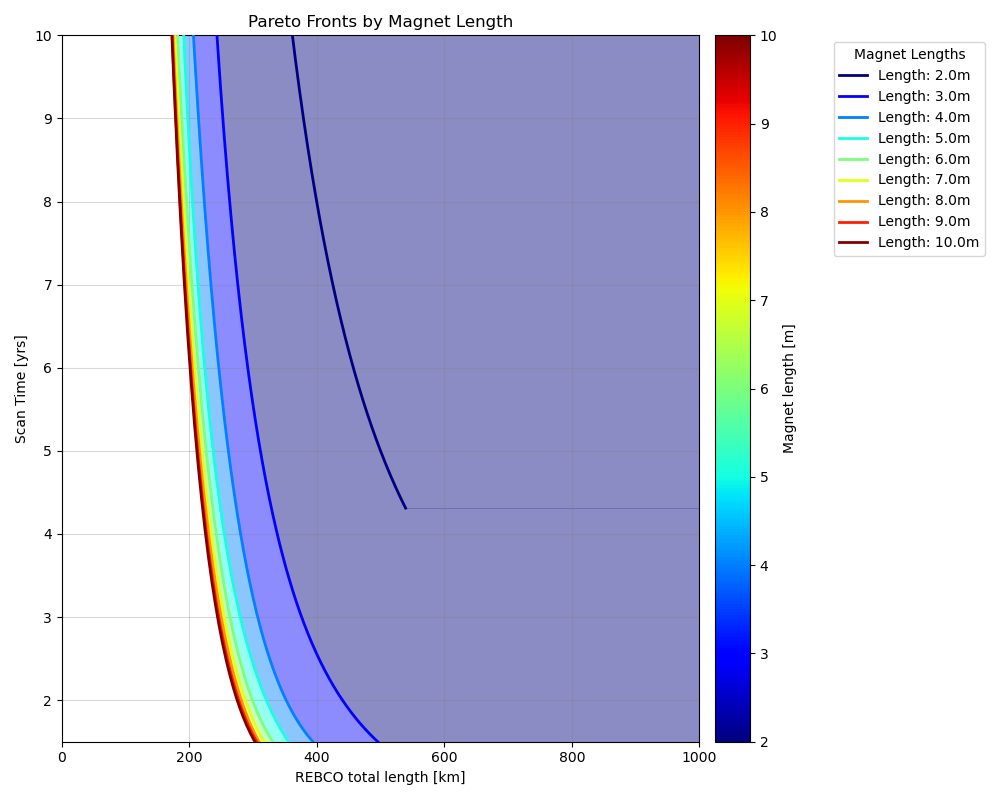

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import glob
import os
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

# ----------------------------- user settings --------------------------------
CMAP        = plt.cm.jet     # or plt.cm.rainbow / plt.cm.turbo
FILL_ALPHA  = 0.45           # transparency of the bands between two curves
Y_TOP       = 10.0           # top of the plotting window
X_LIM       = (0.0, 1000.0)
FILL_TO_TOP = True           # also shade from the uppermost curve up to Y_TOP
BAND_FROM_LOWER_LENGTH = True  # band takes the colour of the shorter-magnet curve
SAVE_PER_LENGTH_CSV = True   # also write one Pareto CSV per magnet length
# -----------------------------------------------------------------------------


def power_law(x, a, b, c):
    x_safe = np.maximum(x, 1e-5)
    return a * (x_safe ** -b) + c


def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c


file_list = sorted(glob.glob('thickness_grids_L*.csv'))

pareto_tables = []   # list of DataFrames, one per input file (full magnet info)
all_fit_equations = []
curves = []          # everything needed for plotting, filled in pass 1

# =============================================================================
# PASS 1 - read the data, build the Pareto fronts and fit them
# =============================================================================
for file_path in file_list:
    df_all = pd.read_csv(file_path)

    if 'solenoid_length_m' in df_all.columns:
        length_val = df_all['solenoid_length_m'].iloc[0]
        label_name = f'Length: {length_val}m'
    else:
        length_val = os.path.basename(file_path)
        label_name = str(length_val)

    df_filtered = df_all[(df_all['scan'] >= 0.95) &
                         (df_all['scan'] <= 11.0)].reset_index(drop=True)
    if len(df_filtered) == 0:
        continue

    df_sorted = df_filtered.sort_values(by=['length_tape_km', 'scan'])

    # ---- Pareto selection: keep the INDEX of every non-dominated row --------
    pareto_idx = []
    min_y = float('inf')
    for idx, row in df_sorted.iterrows():
        if row['scan'] < min_y:
            pareto_idx.append(idx)
            min_y = row['scan']

    if not pareto_idx:
        continue

    # ---- full rows of the Pareto magnets (every column of the source file) --
    df_pareto = df_sorted.loc[pareto_idx].copy().reset_index(drop=True)
    df_pareto.insert(0, 'source_file', os.path.basename(file_path))
    if 'solenoid_length_m' not in df_pareto.columns:
        df_pareto.insert(1, 'solenoid_length_m', length_val)
    df_pareto.insert(1, 'pareto_rank', np.arange(1, len(df_pareto) + 1))

    pareto_tables.append(df_pareto)

    if SAVE_PER_LENGTH_CSV:
        tag = str(length_val).replace('.', '_').replace('/', '_')
        df_pareto.to_csv(f'pareto_magnets_L{tag}.csv', index=False)

    # ---- arrays used for the fitting / plotting ------------------------------
    px_arr = df_pareto['length_tape_km'].to_numpy(dtype=float)
    py_arr = df_pareto['scan'].to_numpy(dtype=float)

    px_unique, idx_u = np.unique(px_arr, return_index=True)
    py_unique = py_arr[idx_u]

    if len(px_unique) < 2:
        continue

    x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
    evaluator = None
    fit_label = ''
    y_curve = None

    if len(px_unique) >= 3:
        best_error = float('inf')
        best_params, best_func, best_name = None, None, ''

        for func, name in ((power_law, 'Power Law'),
                           (exponential_decay, 'Exponential')):
            try:
                p0 = [py_unique.max(), 0.1, py_unique.min()]
                popt, _ = curve_fit(func, px_unique, py_unique,
                                    p0=p0, maxfev=10000)
                residuals = py_unique - func(px_unique, *popt)
                ssr = float(np.sum(residuals ** 2))
                if ssr < best_error:
                    best_error, best_params = ssr, popt
                    best_func, best_name = func, name
            except Exception:
                continue

        if best_func is not None:
            evaluator = (lambda x, f=best_func, p=best_params: f(x, *p))
            fit_label = f'Fit: {best_name}'
            all_fit_equations.append({
                'solenoid_length_m': length_val,
                'function_type': best_name,
                'param_a': best_params[0],
                'param_b': best_params[1],
                'param_c': best_params[2],
                'sum_squared_error': best_error
            })

    if evaluator is None:                      # 2 points, or fitting failed
        spline = PchipInterpolator(px_unique, py_unique)
        evaluator = (lambda x, s=spline: s(x))
        fit_label = 'Fit: Spline (fallback)'
        label_name_plot = label_name + ' (spline)'
    else:
        label_name_plot = label_name

    y_curve = evaluator(x_smooth)

    try:
        sort_value = float(length_val)
    except (TypeError, ValueError):
        sort_value = float('inf')

    curves.append({
        'label':  label_name_plot,
        'length': sort_value,
        'x':      x_smooth,
        'y':      y_curve,
        'eval':   evaluator,
        'xmin':   float(px_unique.min()),
        'xmax':   float(px_unique.max()),
        'px':     px_unique,
        'py':     py_unique,
        'fit_label': fit_label,
    })

# =============================================================================
# Colour mapping: shortest magnet -> one end of jet, longest -> the other end
# =============================================================================
curves.sort(key=lambda c: c['length'])

lengths = np.array([c['length'] for c in curves], dtype=float)
finite = lengths[np.isfinite(lengths)]
if finite.size == 0:
    norm = mpl.colors.Normalize(0, max(len(curves) - 1, 1))
    for k, c in enumerate(curves):
        c['color'] = CMAP(norm(k))
else:
    lo, hi = finite.min(), finite.max()
    if lo == hi:
        lo, hi = lo - 0.5, hi + 0.5
    norm = mpl.colors.Normalize(vmin=lo, vmax=hi)
    for c in curves:
        v = c['length'] if np.isfinite(c['length']) else hi
        c['color'] = CMAP(norm(v))

# =============================================================================
# PASS 2 - aggregate figure: bands between neighbouring curves + the lines
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 8))

if curves:
    # common grid so that neighbouring curves can be filled against each other
    x_common = np.linspace(min(c['xmin'] for c in curves),
                           max(c['xmax'] for c in curves), 800)
    # constant extrapolation outside each curve's own data range
    Y = np.vstack([c['eval'](np.clip(x_common, c['xmin'], c['xmax']))
                   for c in curves])

    # shade the region between every pair of neighbouring Pareto fronts
    for i in range(len(curves) - 1):
        band_color = curves[i]['color'] if BAND_FROM_LOWER_LENGTH \
                     else curves[i + 1]['color']
        ax1.fill_between(x_common, Y[i], Y[i + 1],
                         color=band_color, alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    # shade from the uppermost curve to the top of the axes with its own colour
    if FILL_TO_TOP:
        top_idx = int(np.argmax(np.nanmean(Y, axis=1)))
        ax1.fill_between(x_common, Y[top_idx], Y_TOP,
                         color=curves[top_idx]['color'], alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    # the fitted lines on top
    handles, labels = [], []
    for c in curves:
        ln, = ax1.plot(c['x'], c['y'], color=c['color'],
                       linewidth=2, label=c['label'], zorder=3)
        handles.append(ln)
        labels.append(c['label'])

# ---------------------------- individual plots -------------------------------
for c in curves:
    fig_ind, ax_ind = plt.subplots(figsize=(8, 6))
    ax_ind.scatter(c['px'], c['py'], color='black',
                   label='Pareto Points', zorder=4)
    ax_ind.plot(c['x'], c['y'], color=c['color'], linewidth=2,
                label=c['fit_label'], zorder=3)
    ax_ind.set_xlabel('REBCO total length [km]')
    ax_ind.set_ylabel('Scan Time [yrs]')
    ax_ind.set_title(f"Pareto Front and Fit - {c['label']}")
    ax_ind.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
    ax_ind.legend()
    fig_ind.tight_layout()
    safe_filename = str(c['length']).replace('.', '_').replace('/', '_')
    fig_ind.savefig(f'individual_fit_{safe_filename}.png', dpi=150)
    plt.close(fig_ind)

# ------------------------------- CSV output ----------------------------------
if pareto_tables:
    df_pareto_all = pd.concat(pareto_tables, ignore_index=True, sort=False)

    # keep the identifying columns first, then everything else from the source
    lead = [c for c in ('source_file', 'pareto_rank', 'solenoid_length_m',
                        'length_tape_km', 'scan') if c in df_pareto_all.columns]
    rest = [c for c in df_pareto_all.columns if c not in lead]
    df_pareto_all = df_pareto_all[lead + rest]

    df_pareto_all.to_csv('saved_pareto_fronts.csv', index=False)
    print(f"Saved {len(df_pareto_all)} Pareto magnets with "
          f"{df_pareto_all.shape[1]} columns to 'saved_pareto_fronts.csv'")

    if all_fit_equations:
        pd.DataFrame(all_fit_equations).to_csv('saved_pareto_equations.csv',
                                               index=False)
        print("Mathematical fit parameters saved to 'saved_pareto_equations.csv'")
else:
    print("No Pareto points were generated to save.")

print("Individual plots have been saved as PNG files in the current directory.")

# ------------------------------- cosmetics -----------------------------------
ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(*X_LIM)
ax1.set_ylim(1.5, Y_TOP)
ax1.set_title('Pareto Fronts by Magnet Length')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=CMAP)
sm.set_array([])
cbar = fig1.colorbar(sm, ax=ax1, pad=0.02)
cbar.set_label('Magnet length [m]')

ax1.legend(handles, labels, title='Magnet Lengths',
           bbox_to_anchor=(1.20, 1), loc='upper left')

fig1.tight_layout()
plt.show()

# Global Scatter Plots — Scan Time and Field/Volume Positioning

Concatenates every `thickness_grids_L*.csv` in the working directory into one
frame and produces three standalone figures over the whole design database,
with no per-length faceting.

## Filtering

A single window, `1.0 <= scan <= 10.0` yr, is applied once to produce
`df_filtered`; all three figures share it. Figures 1 and 2 set their y-limits to
that same window, so the filter and the visible range coincide and nothing is
clipped. Figure 3 reuses the bounds as `vmin`/`vmax` on the scan-time colour
scale, so its colours are directly comparable to the y-positions in Figures 1
and 2.

## Figures

**1 and 2** plot scan time against total tape length (km) and against tape
length per pancake (m), coloured by `solenoid_length_m`. Both autoscale the
upper x-limit from the data.

**3** plots `b0` against `v` for the design database, coloured by scan time, and
overlays five reference families: user-defined operating points (stars,
coloured by cavity Q), built axion solenoids (orange diamonds), built REBCO
high-field solenoids (green triangles), designed/future REBCO solenoids (red
inverted triangles), MRI solenoids (blue squares) and collider detector
solenoids (purple hexagons). Each overlay point is labelled through
`label_layout`, keyed by name, giving an offset in points plus horizontal and
vertical alignment; unlisted names fall back to a per-family default. Repeated
`label=` arguments are collapsed by the `by_label` dict before the legend is
drawn.

Clicking any database point in any figure opens a tooltip with its full
parameter set. Overlay points are not pickable.

> Figure 3's x-axis is linear and hard-limited to 0–50 m³ while the plotted
> volumes span about six orders of magnitude. Every non-collider reference point
> renders against the y-axis, and coincident points are separated only by their
> label offsets. Any database design above 50 m³ is off-screen.
>
> Volume conventions differ between the reference blocks; the collider, axion
> and MRI figures are bore volumes, while the built-REBCO figures appear to be
> field-homogeneity volumes. Confirm before reading across families.
>
> `custom_points` tuples carry two fields that are unpacked and discarded
> (positions 4 and 5, apparently noise floor and scan time); only `b0`, `v`,
> `Q` and the name reach the plot.
>
> If the input files have no `v` column, Figure 3 silently plots the entire
> database at v = 0 rather than raising.
>
> Tooltips need `%matplotlib widget` and a live kernel. This cell also assumes
> `glob` and `pandas` are already imported.

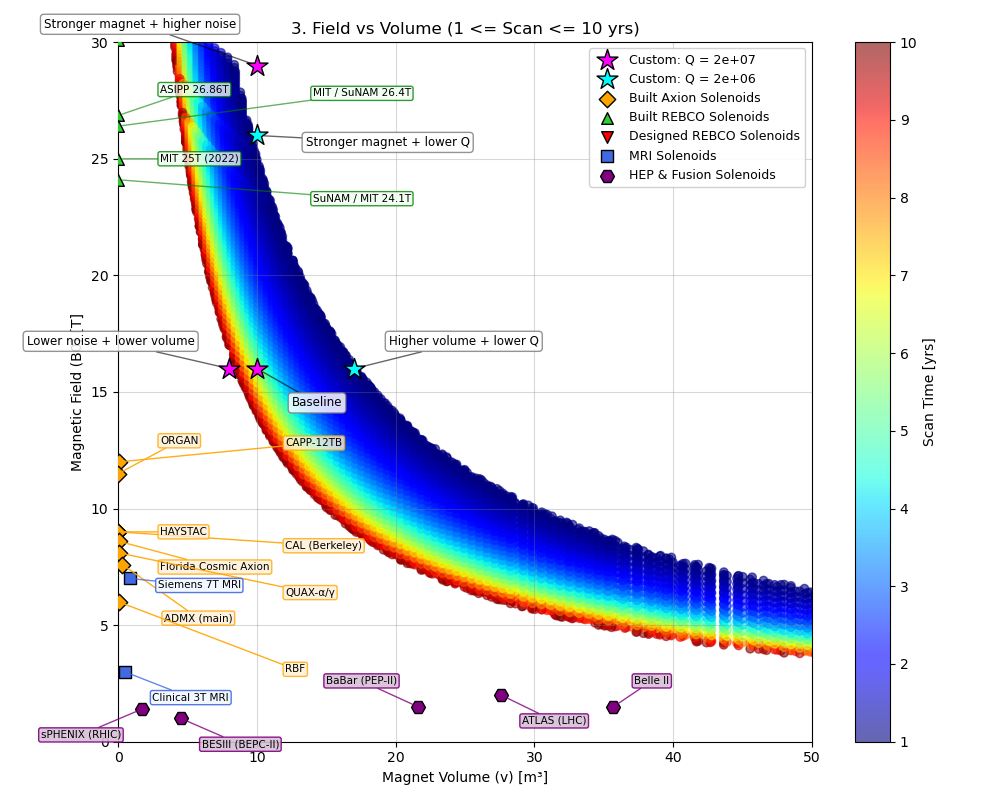

In [23]:
# -------------------------------------------------------------------------
# GLOBAL SCATTER PLOTS (Figs 1, 2, 3)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import glob
import pandas as pd
# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)


def setup_single_annotation(fig, ax, scatter_obj, data_df):
    annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                        bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=8, zorder=10)
    annot.set_visible(False)

    def on_pick(event):
        if event.artist != scatter_obj:
            return
            
        ind = event.ind[0]
        row = data_df.iloc[ind]

        x, y = event.artist.get_offsets()[ind]
        
        text = (f"L={row['solenoid_length_m']:.1f} m\n"
                f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                f"B0={row['b0']:.2f} T\n"
                f"Total SC={row['length_tape_km']:.1f} km\n"
                f"Pancake SC={row['pancake_length_m']:.1f} m\n"
                f"Scan={row['scan']:.1f} yrs\n"
                f"Vol={row.get('v', 0):.2f}")

        annot.xy = (x, y)
        annot.set_text(text)
        annot.set_visible(True)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect("pick_event", on_pick)


# --- 1. FILTERING & AXIS CONTROLS ---

# Filter out magnets with a scan time outside the 1 to 10 year range
min_scan_years = 1.0
max_scan_years = 10
df_filtered = df_all[(df_all['scan'] >= min_scan_years) & (df_all['scan'] <= max_scan_years)].reset_index(drop=True)

# Axis limits for Graph 1 & 2
g1_xlim = (0, None)
g1_ylim = (min_scan_years, max_scan_years)
g2_xlim = (0, None)
g2_ylim = (min_scan_years, max_scan_years)

# Axis limits for Graph 3
g3_xlim = (0, 50) 
g3_ylim = (0, 30) 


# # -------------------------------------------------------------------------
# # 1. Scan time vs REBCO total length 
# # -------------------------------------------------------------------------

# fig1, ax1 = plt.subplots(figsize=(8, 6))
# scat1 = ax1.scatter(df_filtered['length_tape_km'], df_filtered['scan'], 
#                     c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, picker=5)
# fig1.colorbar(scat1, ax=ax1, label='Solenoid Length [m]')
# ax1.set_xlabel('REBCO total length [km]')
# ax1.set_ylabel('Scan Time [yrs]')
# ax1.set_xlim(g1_xlim)
# ax1.set_ylim(g1_ylim)
# ax1.set_title('1. Scan Time vs Total REBCO Length (1 <= Scan <= 10 yrs)')
# ax1.grid(True, linestyle='-', color='gray', alpha=0.3)
# setup_single_annotation(fig1, ax1, scat1, df_filtered)
# fig1.tight_layout()

# # -------------------------------------------------------------------------
# # 2. Scan time vs REBCO length per pancake 
# # -------------------------------------------------------------------------
# fig2, ax2 = plt.subplots(figsize=(8, 6))
# scat2 = ax2.scatter(df_filtered['pancake_length_m'], df_filtered['scan'], 
#                     c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, picker=5)
# fig2.colorbar(scat2, ax=ax2, label='Solenoid Length [m]')
# ax2.set_xlabel('REBCO length per pancake [m]')
# ax2.set_ylabel('Scan Time [yrs]')
# ax2.set_xlim(g2_xlim)
# ax2.set_ylim(g2_ylim)
# ax2.set_title('2. Scan Time vs Pancake Length (1 <= Scan <= 10 yrs)')
# ax2.grid(True, linestyle='-', color='gray', alpha=0.3)
# setup_single_annotation(fig2, ax2, scat2, df_filtered)
# fig2.tight_layout()

# -------------------------------------------------------------------------
# 3. Field vs Volume + Custom Points + Axion, REBCO, MRI, and HEP/Fusion
# -------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 8)) # Made slightly wider to accommodate text spacing

vol_data = df_filtered['v'] if 'v' in df_filtered.columns else df_filtered['b0'] 

# Background scatter points (Main DB)
scat3 = ax3.scatter(vol_data, df_filtered['b0'], 
                    c=df_filtered['scan'], cmap='jet', alpha=0.6, picker=5, 
                    vmin=min_scan_years, vmax=max_scan_years)
fig3.colorbar(scat3, ax=ax3, label='Scan Time [yrs]')

# --- DEFINITIONS ---

# Custom user points
custom_points = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q')
]
q_colors = {20e6: 'magenta', 2e6: 'cyan'}

# Axion built solenoids
axion_magnets = [
    (12.0, 0.021, 'CAPP-12TB'),
    (11.5, 0.000048, 'ORGAN'),
    (9.0,  0.007, 'CAL (Berkeley)'),
    (9.0,  0.002, 'HAYSTAC'),
    (8.6,  0.008, 'Florida Cosmic Axion'),
    (8.1,  0.009, 'QUAX-α/γ'),
    (7.6,  0.283, 'ADMX (main)'),
    (6.0,  0.011, 'RBF')
]

# REBCO Built high-field solenoids 
rebco_built = [
    (45.5, 0.000008, 'LBC3 (NHMFL) 45.5T'),
    (44.0, 0.000008, 'LBC4-5 (NHMFL) 44T'),
    (43.0, 0.000008, 'LBC6 (NHMFL) 43T'),
    (42.5, 0.000008, 'LBC2 (NHMFL) 42.5T'),
    (40.2, 0.000008, 'LBC1 (NHMFL) 40.2T'),
    (32.5, 0.000240, 'NOUGAT 32.5T'),
    (32.4, 0.000100, 'ASIPP 32.4T'),
    (32.35, 0.000200, 'IEE CAS 32.35T'),
    (32.0, 0.000200, 'NHMFL 32T all-SC'),
    (31.4, 0.000050, 'RIKEN 31.4T'),
    (30.1, 0.000200, 'IEE CAS 30.1T'),
    (26.86, 0.000150, 'ASIPP 26.86T'),
    (26.4, 0.000300, 'MIT / SuNAM 26.4T'),
    (25.0, 0.000150, 'MIT 25T (2022)'),
    (24.1, 0.000050, 'SuNAM / MIT 24.1T')
]

# REBCO Designed/Future high-field solenoids
rebco_designed = [
    (40.0, 0.00137, 'Muon Collider (CERN) 40T'),
    (40.0, 0.00020, 'NHMFL 40T Project'),
    (40.0, 0.00100, 'SuperEMFL 40T+')
]

# MRI Solenoidal Magnets
mri_magnets = [
    (7.0, 0.835, 'Siemens 7T MRI'),     
    (3.0, 0.452, 'Clinical 3T MRI')     
]

# High Energy Physics (HEP) & ITER Fusion Solenoids (Calculated Vol = pi * r^2 * h)
hep_fusion_magnets = [
    (1.5, 35.7, 'Belle II'),               # Bore 3.4m, L 3.937m
    (2.0, 27.6, 'ATLAS (LHC)'),            # Bore 2.46m, L 5.8m
    (1.5, 21.6, 'BaBar (PEP-II)'),         # Bore 2.8m, L 3.512m
    (1.0, 4.5, 'BESIII (BEPC-II)'),        # Bore 1.28m, L 3.52m
    (1.4, 1.7, 'sPHENIX (RHIC)')           # Bore 1.4m, L 1.1m
]

# Custom offset dictionary (X_offset, Y_offset, H_align, V_align)
label_layout = {
    # Custom Points
    'Baseline':                       (25, -20, 'left', 'top'),
    'Stronger magnet + higher noise': (-15, 25, 'right', 'bottom'),
    'Lower noise + lower volume':     (-25, 15, 'right', 'bottom'),
    'Higher volume + lower Q':        (25, 15, 'left', 'bottom'),
    'Stronger magnet + lower Q':      (35, -5, 'left', 'center'),
    
    # Axion Magnets
    'ORGAN':                (30, 20, 'left', 'bottom'),
    'CAPP-12TB':            (120, 10, 'left', 'bottom'),
    'HAYSTAC':              (30, 0,  'left', 'center'),
    'CAL (Berkeley)':       (120, -10, 'left', 'center'),
    'Florida Cosmic Axion': (30, -15, 'left', 'top'),
    'QUAX-α/γ':             (120, -25, 'left', 'top'),
    'ADMX (main)':          (30, -35, 'left', 'top'),
    'RBF':                  (120, -45, 'left', 'top'),
    
    # Built REBCO 
    'LBC3 (NHMFL) 45.5T':  (30, 10, 'left', 'bottom'),
    'LBC4-5 (NHMFL) 44T':  (140, 15, 'left', 'bottom'),
    'LBC6 (NHMFL) 43T':    (30, -5, 'left', 'top'),
    'LBC2 (NHMFL) 42.5T':  (140, 0, 'left', 'center'),
    'LBC1 (NHMFL) 40.2T':  (30, -20, 'left', 'top'),
    
    'NOUGAT 32.5T':        (30, 15, 'left', 'bottom'),
    'ASIPP 32.4T':         (120, 25, 'left', 'bottom'),
    'IEE CAS 32.35T':      (220, 15, 'left', 'bottom'),
    'NHMFL 32T all-SC':    (30, 0, 'left', 'center'),
    'RIKEN 31.4T':         (120, 0, 'left', 'center'),
    'IEE CAS 30.1T':       (220, -5, 'left', 'center'),
    
    'ASIPP 26.86T':        (30, 15, 'left', 'bottom'),
    'MIT / SuNAM 26.4T':   (140, 20, 'left', 'bottom'),
    'MIT 25T (2022)':      (30, 0, 'left', 'center'),
    'SuNAM / MIT 24.1T':   (140, -10, 'left', 'top'),
    
    # Designed REBCO
    'Muon Collider (CERN) 40T': (250, 25, 'left', 'bottom'),
    'NHMFL 40T Project':        (250, 0, 'left', 'center'),
    'SuperEMFL 40T+':           (250, -25, 'left', 'top'),

    # MRI Solenoids
    'Siemens 7T MRI':   (20, -5, 'left', 'center'),
    'Clinical 3T MRI':  (20, -15, 'left', 'top'),

    # HEP / Fusion Solenoids
    'ALICE (LHC)':           (-20, 15, 'right', 'bottom'),
    'CMS (LHC)':             (15, 15, 'left', 'bottom'),
    'ITER Central Solenoid': (15, 15, 'left', 'bottom'),
    'STAR (RHIC)':           (15, -15, 'left', 'top'),
    'KLOE (DAFNE)':          (-15, -15, 'right', 'top'),
    'Belle II':              (15, 15, 'left', 'bottom'),
    'ATLAS (LHC)':           (15, -15, 'left', 'top'),
    'BaBar (PEP-II)':        (-15, 15, 'right', 'bottom'),
    'BESIII (BEPC-II)':      (15, -15, 'left', 'top'),
    'sPHENIX (RHIC)':        (-15, -15, 'right', 'top')
}

# --- PLOTTING CUSTOM POINTS ---
for pt in custom_points:
    b0, v_m3, q, _, _, name = pt
    pt_color = q_colors.get(q, 'white')
    ax3.scatter(v_m3, b0, color=pt_color, edgecolor='black', s=250, marker='*', zorder=5, label=f'Custom: Q = {q:.0e}')
    x_off, y_off, ha, va = label_layout.get(name, (15, 15, 'left', 'bottom'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=8.5, zorder=6,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.85, edgecolor='gray'),
                 arrowprops=dict(arrowstyle="-", color='black', alpha=0.6, shrinkA=0, shrinkB=5))

# --- PLOTTING AXION MAGNETS ---
for pt in axion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='orange', edgecolor='black', s=70, marker='D', zorder=5, label='Built Axion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='papayawhip', alpha=0.8, edgecolor='orange'),
                 arrowprops=dict(arrowstyle="-", color='orange', alpha=0.9, shrinkA=0, shrinkB=3))

# --- PLOTTING BUILT REBCO ---
for pt in rebco_built:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='limegreen', edgecolor='black', s=70, marker='^', zorder=5, label='Built REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (30, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='honeydew', alpha=0.8, edgecolor='green'),
                 arrowprops=dict(arrowstyle="-", color='green', alpha=0.6, shrinkA=0, shrinkB=3))

# --- PLOTTING DESIGNED REBCO ---
for pt in rebco_designed:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='red', edgecolor='black', s=70, marker='v', zorder=5, label='Designed REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (40, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='mistyrose', alpha=0.9, edgecolor='red'),
                 arrowprops=dict(arrowstyle="-", color='red', alpha=0.6, shrinkA=0, shrinkB=3))

# --- PLOTTING MRI SOLENOIDS ---
for pt in mri_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='royalblue', edgecolor='black', s=80, marker='s', zorder=5, label='MRI Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='aliceblue', alpha=0.9, edgecolor='royalblue'),
                 arrowprops=dict(arrowstyle="-", color='royalblue', alpha=0.8, shrinkA=0, shrinkB=4))

# --- PLOTTING HEP & FUSION SOLENOIDS ---
for pt in hep_fusion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='purple', edgecolor='black', s=100, marker='H', zorder=5, label='HEP & Fusion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='thistle', alpha=0.9, edgecolor='purple'),
                 arrowprops=dict(arrowstyle="-", color='purple', alpha=0.8, shrinkA=0, shrinkB=4))

handles, labels = ax3.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys(), loc='upper right', framealpha=0.9, fontsize=9)

ax3.set_xlabel('Magnet Volume (v) [m³]')
ax3.set_ylabel('Magnetic Field (B0) [T]')
ax3.set_xlim(g3_xlim)
ax3.set_ylim(g3_ylim)
ax3.set_title('3. Field vs Volume (1 <= Scan <= 10 yrs)')
ax3.grid(True, linestyle='-', color='gray', alpha=0.3)
setup_single_annotation(fig3, ax3, scat3, df_filtered)
fig3.tight_layout()

plt.show()







1090 scan points with scan in [2.75, 3.25] yrs
lengths present: [ 3.  4.  5.  6.  7.  8.  9. 10.]


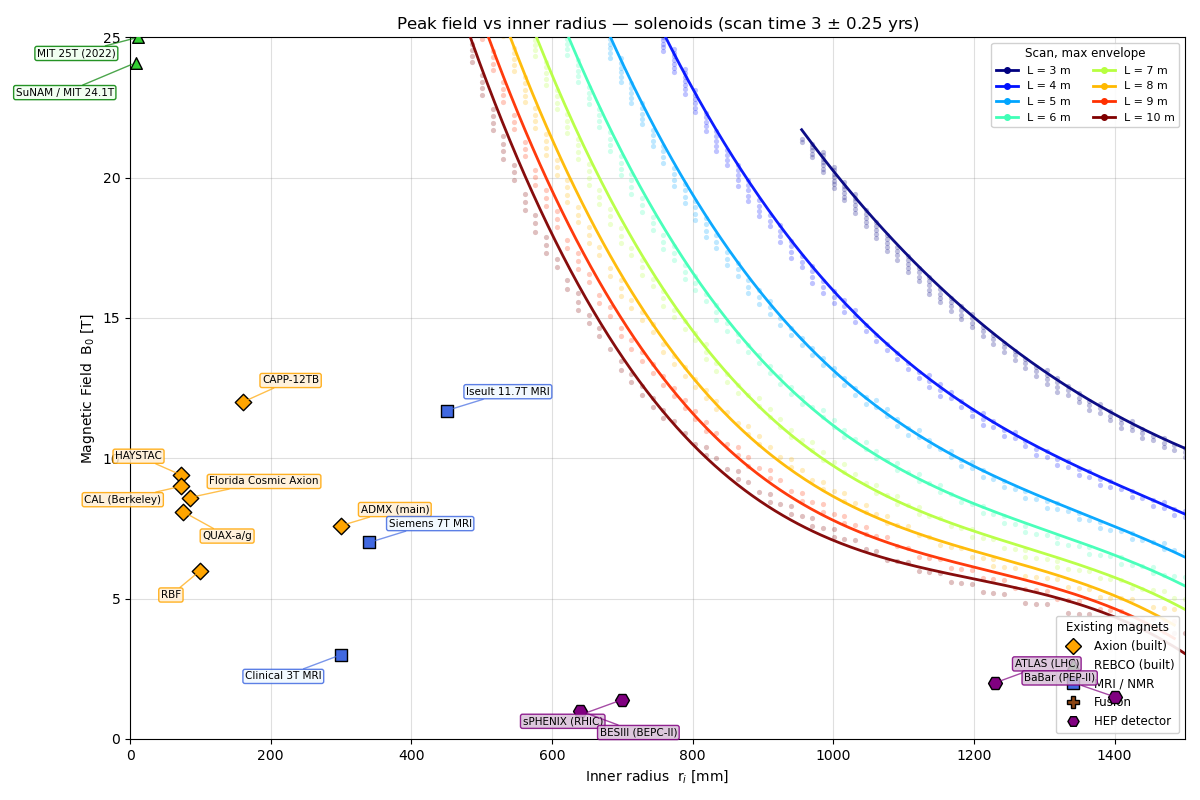

In [24]:
# -------------------------------------------------------------------------
# MAGNET LANDSCAPE PLOT
#   Field (y) vs Inner Radius (x)
#   Background = parametric scan at ~3 years scan time (all lengths)
#   One fitted curve per solenoid length, coloured jet (small = blue, large = red)
#   Linear axes, two legends (lengths / magnet categories)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import numpy as np
import glob
import pandas as pd

# -------------------------------------------------------------------------
# 0. USER CONTROLS
# -------------------------------------------------------------------------
target_scan_years = 3.0     # scan time to select
scan_tol_years    = 0.25    # +/- tolerance around the target

SHOW_BACKGROUND  = True     # draw the raw scan points
SHOW_POINTS      = True     # faint scatter underlay
SHOW_FITS        = True     # fitted curve per length
ANNOTATE_MAGNETS = True

ENVELOPE = 'max'            # 'max' | 'min' | 'none'  -> how to collapse th at fixed ri
FIT_MODE = 'poly'           # 'poly' | 'spline' | 'raw'
POLY_DEG = 3                # polynomial degree for FIT_MODE='poly'
SPLINE_SMOOTH = None        # None -> auto; float -> UnivariateSpline s parameter
N_FIT = 300                 # points used to draw each fitted curve

figB_xlim = (0, 1500)       # inner radius [mm]   (linear)
figB_ylim = (0, 25)         # field [T]

# -------------------------------------------------------------------------
# 1. LOAD PARAMETRIC SCAN DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
if file_list:
    df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)
    lo = target_scan_years - scan_tol_years
    hi = target_scan_years + scan_tol_years
    df_filtered = df_all[(df_all['scan'] >= lo) &
                         (df_all['scan'] <= hi)].reset_index(drop=True)
    print(f"{len(df_filtered)} scan points with scan in [{lo:.2f}, {hi:.2f}] yrs")
    if len(df_filtered) and 'solenoid_length_m' in df_filtered.columns:
        print("lengths present:",
              np.sort(df_filtered['solenoid_length_m'].unique()))
    if df_filtered.empty:
        print("WARNING: no points in the tolerance window -> widen scan_tol_years.")
        SHOW_BACKGROUND = False
else:
    print("WARNING: no 'thickness_grids_L*.csv' found -> background disabled.")
    df_filtered = pd.DataFrame(columns=['ri', 'th', 'b0', 'v', 'scan',
                                        'length_tape_km', 'pancake_length_m',
                                        'solenoid_length_m'])
    SHOW_BACKGROUND = False


# -------------------------------------------------------------------------
# 1b. FIT HELPERS
# -------------------------------------------------------------------------
def make_envelope(sub, mode=ENVELOPE):
    """Collapse the (ri, th) cloud of one length into a single b0(ri) curve."""
    if mode == 'none':
        g = sub[['ri', 'b0']].sort_values('ri')
        return g['ri'].to_numpy(), g['b0'].to_numpy()
    agg = 'max' if mode == 'max' else 'min'
    g = sub.groupby('ri', as_index=False)['b0'].agg(agg).sort_values('ri')
    return g['ri'].to_numpy(), g['b0'].to_numpy()


def fit_curve(x, y, mode=FIT_MODE, deg=POLY_DEG, n=N_FIT):
    """Return a smooth (xs, ys) representation of the envelope."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if x.size < 2:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    if mode == 'raw' or x.size < 4:
        return x, y

    xs = np.linspace(x.min(), x.max(), n)

    if mode == 'spline':
        try:
            from scipy.interpolate import UnivariateSpline
            # spline needs strictly increasing x
            xu, idx = np.unique(x, return_index=True)
            yu = y[idx]
            k = min(3, xu.size - 1)
            s = SPLINE_SMOOTH if SPLINE_SMOOTH is not None else len(xu) * np.var(yu) * 1e-3
            spl = UnivariateSpline(xu, yu, k=k, s=s)
            xs = np.linspace(xu.min(), xu.max(), n)
            return xs, spl(xs)
        except Exception as exc:
            print(f"  spline failed ({exc}) -> falling back to polynomial")

    d = int(min(deg, x.size - 1))
    coef = np.polyfit(x, y, d)
    return xs, np.polyval(coef, xs)


# -------------------------------------------------------------------------
# 1c. INTERACTIVE PICK ANNOTATION (handles several scatter objects)
# -------------------------------------------------------------------------
def setup_pick_annotation(fig, ax, pairs):
    """pairs = list of (scatter_artist, dataframe) with matching row order."""
    annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                        bbox=dict(boxstyle="round", fc="w", alpha=0.9),
                        fontsize=8, zorder=20)
    annot.set_visible(False)
    lookup = {id(artist): sub for artist, sub in pairs}

    def on_pick(event):
        sub = lookup.get(id(event.artist))
        if sub is None:
            return
        ind = event.ind[0]
        row = sub.iloc[ind]
        x, y = event.artist.get_offsets()[ind]
        annot.xy = (x, y)
        annot.set_text(f"L={row['solenoid_length_m']:.1f} m\n"
                       f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                       f"B0={row['b0']:.2f} T\n"
                       f"Total SC={row['length_tape_km']:.1f} km\n"
                       f"Pancake SC={row['pancake_length_m']:.1f} m\n"
                       f"Scan={row['scan']:.2f} yrs\n"
                       f"Vol={row.get('v', 0):.3g} m3")
        annot.set_visible(True)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect("pick_event", on_pick)


# -------------------------------------------------------------------------
# 2. MAGNET DATABASE  (name, category, ri [mm], field volume [m3], B0 [T])
# -------------------------------------------------------------------------
MAGNETS = [
    # ---------------- Axion / dark matter (built) ------------------------
    ("CAPP-12TB",             "Axion (built)",     160.0, 0.021,    12.00),
    ("ORGAN",                 "Axion (built)",     None,  4.8e-5,   11.50),
    ("HAYSTAC",               "Axion (built)",      73.0, 0.009,     9.40),
    ("CAL (Berkeley)",        "Axion (built)",      72.0, 0.007,     9.00),
    ("Florida Cosmic Axion",  "Axion (built)",      85.0, 0.008,     8.60),
    ("QUAX-a/g",              "Axion (built)",      75.0, 0.009,     8.10),
    ("ADMX (main)",           "Axion (built)",     300.0, 0.283,     7.60),
    ("RBF",                   "Axion (built)",     100.0, 0.011,     6.00),

    # ---------------- REBCO high field, built ----------------------------
    ("LBC9 (NHMFL) 48.7T",    "REBCO (built)",       7.0, 1.0e-5,   48.70),
    ("LBC3 (NHMFL) 45.5T",    "REBCO (built)",       7.0, 8.0e-6,   45.50),
    ("LBC4-5 (NHMFL) 44T",    "REBCO (built)",       7.0, 8.0e-6,   44.00),
    ("LBC6 (NHMFL) 43T",      "REBCO (built)",       7.0, 8.0e-6,   43.00),
    ("LBC2 (NHMFL) 42.5T",    "REBCO (built)",       7.0, 8.0e-6,   42.50),
    ("LBC1 (NHMFL) 40.2T",    "REBCO (built)",       7.0, 8.0e-6,   40.20),
    ("NOUGAT 32.5T",          "REBCO (built)",      19.0, 2.4e-4,   32.50),
    ("ASIPP 32.4T",           "REBCO (built)",       8.5, 4.0e-5,   32.40),
    ("IEE CAS 32.35T",        "REBCO (built)",      20.0, 2.0e-4,   32.35),
    ("NHMFL 32T all-SC",      "REBCO (built)",      21.5, 2.0e-4,   32.00),
    ("RIKEN 31.4T",           "REBCO (built)",       8.5, 5.0e-5,   31.40),
    ("IEE CAS 30.1T",         "REBCO (built)",      21.5, 2.0e-4,   30.10),
    ("ASIPP 26.86T",          "REBCO (built)",      15.0, 1.5e-4,   26.86),
    ("MIT / SuNAM 26.4T",     "REBCO (built)",      17.5, 3.0e-4,   26.40),
    ("MIT 25T (2022)",        "REBCO (built)",      11.2, 1.5e-4,   25.00),
    ("SuNAM / MIT 24.1T",     "REBCO (built)",       8.5, 5.0e-5,   24.10),

    # ---------------- MRI / NMR ------------------------------------------
    ("Bruker 28.2T NMR",      "MRI / NMR",          27.0, None,     28.19),
    ("Iseult 11.7T MRI",      "MRI / NMR",         450.0, None,     11.70),
    ("Siemens 7T MRI",        "MRI / NMR",         340.0, 0.835,     7.00),
    ("Clinical 3T MRI",       "MRI / NMR",         300.0, 0.452,     3.00),

    # ---------------- Fusion (solenoid) ----------------------------------
    ("ITER Central Solenoid", "Fusion",           2060.0, 158.25,   13.50),

    # ---------------- HEP detector solenoids ------------------------------
    ("CMS (LHC)",             "HEP detector",     2950.0, 341.75,    4.00),
    ("ATLAS (LHC)",           "HEP detector",     1230.0,  27.57,    2.00),
    ("Belle II",              "HEP detector",     1700.0,  35.74,    1.50),
    ("BaBar (PEP-II)",        "HEP detector",     1400.0,  21.63,    1.50),
    ("sPHENIX (RHIC)",        "HEP detector",      700.0,   1.69,    1.40),
    ("BESIII (BEPC-II)",      "HEP detector",      640.0,   4.53,    1.00),
    ("KLOE (DAFNE)",          "HEP detector",     2450.0,  92.40,    0.60),
    ("ALICE (LHC)",           "HEP detector",     5780.0, 740.99,    0.50),
    ("STAR (RHIC)",           "HEP detector",     2500.0, 134.50,    0.50),
]

df_mag = pd.DataFrame(MAGNETS, columns=['name', 'category', 'ri_mm', 'v_m3', 'b0'])

# -------------------------------------------------------------------------
# 3. STYLE PER CATEGORY
# -------------------------------------------------------------------------
STYLE = {
    'Axion (built)':    dict(color='orange',      marker='D', s=70,  box='papayawhip',  edge='orange'),
    'REBCO (built)':    dict(color='limegreen',   marker='^', s=70,  box='honeydew',    edge='green'),
    'MRI / NMR':        dict(color='royalblue',   marker='s', s=80,  box='aliceblue',   edge='royalblue'),
    'Fusion':           dict(color='saddlebrown', marker='P', s=110, box='linen',       edge='saddlebrown'),
    'HEP detector':     dict(color='purple',      marker='H', s=100, box='thistle',     edge='purple'),
}
DEFAULT_STYLE = dict(color='gray', marker='o', s=60, box='white', edge='gray')

# -------------------------------------------------------------------------
# 4. LABEL OFFSETS  (x_off, y_off, ha, va)
# -------------------------------------------------------------------------
OFFSETS_RI = {
    'LBC9 (NHMFL) 48.7T':   ( 16,   6, 'left',  'bottom'),
    'LBC3 (NHMFL) 45.5T':   ( 16,   0, 'left',  'center'),
    'LBC4-5 (NHMFL) 44T':   ( 16,  -6, 'left',  'top'),
    'LBC6 (NHMFL) 43T':     (-16,   6, 'right', 'bottom'),
    'LBC2 (NHMFL) 42.5T':   (-16,  -2, 'right', 'center'),
    'LBC1 (NHMFL) 40.2T':   (-16, -12, 'right', 'top'),
    'NOUGAT 32.5T':         ( 16,  14, 'left',  'bottom'),
    'ASIPP 32.4T':          (-16,  12, 'right', 'bottom'),
    'IEE CAS 32.35T':       ( 16,   8, 'left',  'bottom'),
    'NHMFL 32T all-SC':     ( 16,  -2, 'left',  'center'),
    'RIKEN 31.4T':          (-16,  -8, 'right', 'top'),
    'IEE CAS 30.1T':        ( 16, -14, 'left',  'top'),
    'Bruker 28.2T NMR':     ( 16,  10, 'left',  'bottom'),
    'ASIPP 26.86T':         (-16,   8, 'right', 'bottom'),
    'MIT / SuNAM 26.4T':    ( 16,   8, 'left',  'bottom'),
    'MIT 25T (2022)':       (-16,  -8, 'right', 'top'),
    'SuNAM / MIT 24.1T':    (-16, -18, 'right', 'top'),
    'CAPP-12TB':            ( 14,  12, 'left',  'bottom'),
    'Iseult 11.7T MRI':     ( 14,  10, 'left',  'bottom'),
    'HAYSTAC':              (-14,  10, 'right', 'bottom'),
    'CAL (Berkeley)':       (-14,  -6, 'right', 'top'),
    'Florida Cosmic Axion': ( 14,   8, 'left',  'bottom'),
    'QUAX-a/g':             ( 14, -14, 'left',  'top'),
    'ADMX (main)':          ( 14,   8, 'left',  'bottom'),
    'RBF':                  (-14, -14, 'right', 'top'),
    'ITER Central Solenoid':( 14,  12, 'left',  'bottom'),
    'Siemens 7T MRI':       ( 14,  10, 'left',  'bottom'),
    'CMS (LHC)':            ( 14,  10, 'left',  'bottom'),
    'Clinical 3T MRI':      (-14, -12, 'right', 'top'),
    'ATLAS (LHC)':          ( 14,  10, 'left',  'bottom'),
    'Belle II':             ( 14,  10, 'left',  'bottom'),
    'BaBar (PEP-II)':       (-14,  10, 'right', 'bottom'),
    'sPHENIX (RHIC)':       (-14, -12, 'right', 'top'),
    'BESIII (BEPC-II)':     ( 14, -12, 'left',  'top'),
    'KLOE (DAFNE)':         ( 14, -12, 'left',  'top'),
    'ALICE (LHC)':          (-14,  12, 'right', 'bottom'),
    'STAR (RHIC)':          ( 14, -14, 'left',  'top'),
}

# -------------------------------------------------------------------------
# 5. FIGURE : FIELD vs INNER RADIUS
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

pick_pairs = []
length_handles = []

if SHOW_BACKGROUND and len(df_filtered):
    lengths = np.sort(df_filtered['solenoid_length_m'].unique())
    n = len(lengths)
    try:
        cmap = plt.get_cmap('jet')
    except Exception:
        cmap = mpl.cm.get_cmap('jet')
    colors = [cmap(i / max(n - 1, 1)) for i in range(n)]  # small = blue, large = red

    for L, col in zip(lengths, colors):
        sub = df_filtered[df_filtered['solenoid_length_m'] == L].reset_index(drop=True)

        # raw points (faint, pickable, not in the legend)
        if SHOW_POINTS:
            sc = ax.scatter(sub['ri'] * 1000.0, sub['b0'],
                            color=col, alpha=0.25, s=14, linewidths=0,
                            picker=5, zorder=2)
            pick_pairs.append((sc, sub))

        # fitted curve through the envelope
        if SHOW_FITS:
            xe, ye = make_envelope(sub)
            xs, ys = fit_curve(xe * 1000.0, ye)
            if len(xs):
                ax.plot(xs, ys, color=col, lw=2.0, alpha=0.95, zorder=4)

        length_handles.append(Line2D([], [], color=col, lw=2.0,
                                     marker='o', markersize=4,
                                     label=f'L = {L:g} m'))

# --- magnet database ------------------------------------------------------
sub_mag = df_mag.dropna(subset=['ri_mm', 'b0'])
cat_handles = {}
for _, row in sub_mag.iterrows():
    st = STYLE.get(row['category'], DEFAULT_STYLE)
    ax.scatter(row['ri_mm'], row['b0'], color=st['color'], edgecolor='black',
               s=st['s'], marker=st['marker'], zorder=6)
    if row['category'] not in cat_handles:
        cat_handles[row['category']] = Line2D([], [], linestyle='none',
                                              marker=st['marker'],
                                              markerfacecolor=st['color'],
                                              markeredgecolor='black',
                                              markersize=8,
                                              label=row['category'])
    if ANNOTATE_MAGNETS:
        x_off, y_off, ha, va = OFFSETS_RI.get(row['name'], (14, 8, 'left', 'bottom'))
        ax.annotate(row['name'], xy=(row['ri_mm'], row['b0']),
                    xytext=(x_off, y_off), textcoords='offset points',
                    ha=ha, va=va, fontsize=7.5, zorder=7, color='black',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor=st['box'],
                              alpha=0.85, edgecolor=st['edge']),
                    arrowprops=dict(arrowstyle="-", color=st['edge'],
                                    alpha=0.7, shrinkA=0, shrinkB=3))

# --- cosmetics ------------------------------------------------------------
ax.set_xlabel('Inner radius  r$_i$ [mm]')
ax.set_ylabel('Magnetic Field  B$_0$ [T]')
ax.set_title(f'Peak field vs inner radius — solenoids '
             f'(scan time {target_scan_years:g} $\\pm$ {scan_tol_years:g} yrs)')
if figB_xlim: ax.set_xlim(figB_xlim)
if figB_ylim: ax.set_ylim(figB_ylim)
ax.grid(True, which='both', linestyle='-', color='gray', alpha=0.25)

# two legends: solenoid lengths (lines) and magnet categories (markers)
if length_handles:
    leg1 = ax.legend(handles=length_handles, loc='upper right',
                     title=f'Scan, {ENVELOPE} envelope', fontsize=8,
                     title_fontsize=8.5, framealpha=0.9, ncol=2)
    ax.add_artist(leg1)
    loc2 = 'lower right'
else:
    loc2 = 'upper right'

if cat_handles:
    ax.legend(handles=list(cat_handles.values()), loc=loc2,
              title='Existing magnets', fontsize=8.5,
              title_fontsize=8.5, framealpha=0.9)

if pick_pairs:
    setup_pick_annotation(fig, ax, pick_pairs)

fig.tight_layout()

# -------------------------------------------------------------------------
# 6. OPTIONAL: dump the curated table
# -------------------------------------------------------------------------
df_mag.to_csv('solenoid_landscape.csv', index=False)

plt.show()

# Pareto Fronts by Magnet Length — fitting, fixed-scan-time extraction, banded plot

Reads every `thickness_grids_L*.csv`, builds a per-magnet Pareto front in
(REBCO tape length, scan time), fits each front, extracts real designs at a set
of target scan times, and renders one aggregate figure plus one PNG per magnet.

## Pass 1 — fronts and fits

Rows are filtered to `SCAN_MIN <= scan <= SCAN_MAX`, sorted by
`(length_tape_km, scan)`, and swept once keeping any row whose scan time beats
every cheaper design. Because the sort breaks ties on scan ascending, the
fastest design at a given tape length always wins; `KEEP_TIES` additionally
retains equal-scan designs at higher tape cost. The retained rows keep their
full design vector, so `saved_pareto_fronts.csv` carries every grid column plus
`source_file` and `pareto_rank`.

Each front with three or more unique x-values is fitted with both `power_law`
and `exponential_decay`, and the lower sum of squared residuals wins. Two-point
fronts, and fronts where both `curve_fit` calls raise, fall back to a Pchip
spline. Fitted coefficients are written with their `x_fit_min`/`x_fit_max`
validity range, which callers must respect: neither functional form is
constrained to stay monotone or positive outside the fitted interval.

## Fixed scan times

For each magnet and each entry in `TARGET_SCANS`, designs within
`target ± margin` are collected from either the front or the full windowed grid
(`SEARCH_POOL`). `PICK_RULE` selects one: `closest` minimises absolute scan
error, `cheapest` minimises tape, `cheapest_not_slower` minimises tape among
designs at or faster than target. Empty windows either return the nearest
design flagged `outside_window`, or a stub row flagged `no_match`. Outputs are
the selection, optionally every in-window candidate, and a target × magnet-length
pivot of tape cost.

## Pass 2 — plotting

Curves are sorted by magnet length and coloured through a single `Normalize`
shared with the colourbar. Neighbouring curves are evaluated on a common x-grid
with constant extrapolation beyond each curve's own data range and filled
against each other, giving contiguous bands only while the curves do not cross.

> `SCAN_MIN` must sit below `min(TARGET_SCANS) - SCAN_MARGIN`, or the first
> target's acceptance window is partly outside the data and the fallback
> "nearest design" is nearest only within the filter.
>
> The Pareto front is the front of the scan-filtered subset, not of the grid.
>
> `EXPORT_COLUMNS` also prunes the frame used as the `'pareto'` search pool; it
> must retain `scan` and `length_tape_km`.
>
> Magnets with fewer than two unique front points are written to the CSVs but
> not plotted. Spline-fallback magnets are omitted from the equations CSV.
>
> With `MARGIN_MODE = 'rel'` the windows for targets 3 and 4 overlap, so one
> design can be selected for both.

/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/148103832.py:44: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/148103832.py:154: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/148103832.py:44: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/148103832.py:44: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/148103832.py:44: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41056/148103832.py:44: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/va

Saved 618 Pareto points with 22 columns to 'saved_pareto_fronts.csv'
  columns: source_file, pareto_rank, solenoid_length_m, length_tape_km, scan, row_i, col_j, ri, rf, th, v, b0, v_bore, je_coil, je_tape, je_max, j_crit, stress, f_tape_min, length_tape, converged, pancake_length_m
Fit parameters (with validity range) saved to 'saved_pareto_equations.csv'

Fixed scan times: 24/27 magnets matched inside the margin -> 'scan_time_points.csv' (31 columns)
  L=2.0  target=1.5 yr: no design within +/-0.25 yr; nearest is 4.317 yr at 539.2 km
  L=2.0  target=2.5 yr: no design within +/-0.25 yr; nearest is 4.317 yr at 539.2 km
  L=2.0  target=3.5 yr: no design within +/-0.25 yr; nearest is 4.317 yr at 539.2 km
Summary (REBCO km vs magnet length) -> 'scan_time_summary.csv'
solenoid_length_m   3.0    4.0    5.0    6.0    7.0    8.0    9.0    10.0
target_scan_yrs                                                          
1.5                497.1  397.8  351.0  331.1  320.6  313.2  300.3  296.3
2.5 

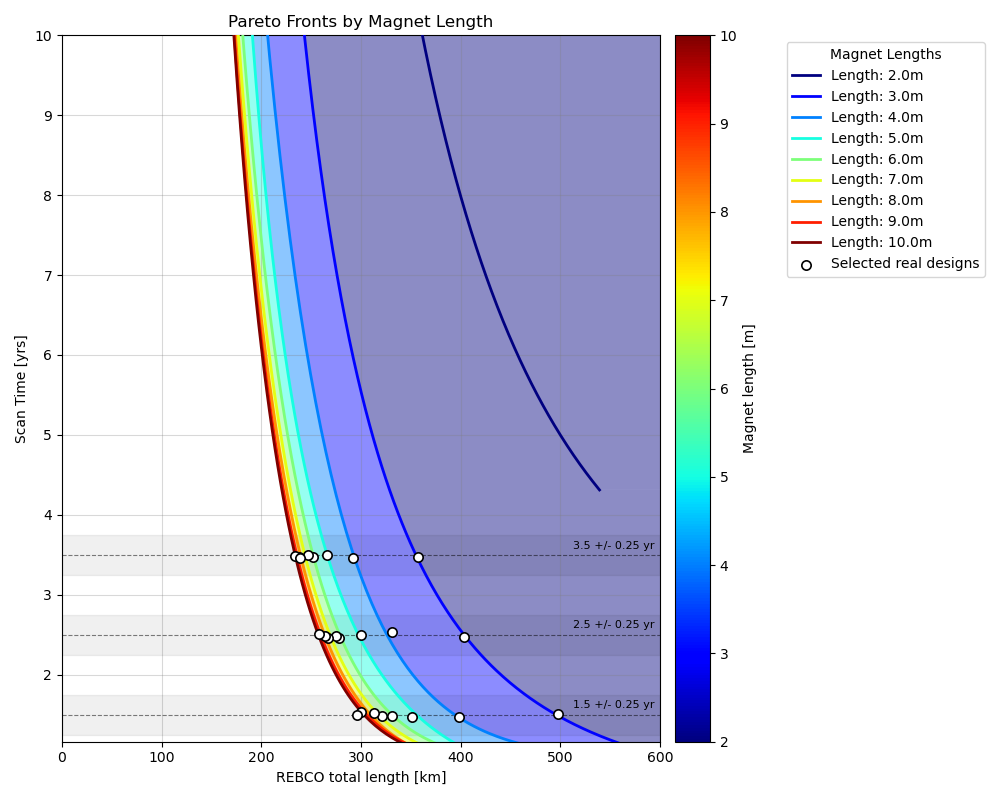

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import glob
import os
import re
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

# ----------------------------- user settings --------------------------------
CMAP        = plt.cm.jet       # or plt.cm.rainbow / plt.cm.turbo
FILL_ALPHA  = 0.45             # transparency of the bands between two curves
Y_TOP       = 10.0             # top of the plotting window
Y_BOTTOM    = 1.16
X_LIM       = (0.0, 600.0)
FILL_TO_TOP = True             # also shade from the uppermost curve up to Y_TOP
BAND_FROM_LOWER_LENGTH = True  # band takes the colour of the shorter-magnet curve
SCAN_MIN, SCAN_MAX = 0.95, 11.0
KEEP_TIES   = False            # keep every design that ties on the objectives
EXPORT_COLUMNS = None          # None = save every column of the grid file,
                               # or e.g. ['length_tape_km', 'scan', 'thickness_m']

# ---- fixed scan-time extraction: REAL designs within a tolerance ------------
TARGET_SCANS     = (1.5, 2.5, 3.5)   # years
SCAN_MARGIN      = 0.25                   # window half-width
MARGIN_MODE      = 'abs'                  # 'abs' -> ±0.25 yr ; 'rel' -> ±25 % of target
SEARCH_POOL      = 'pareto'               # 'pareto' (front only) | 'grid' (all designs)
PICK_RULE        = 'closest'              # 'closest' | 'cheapest' | 'cheapest_not_slower'
FALLBACK_NEAREST = True                   # window empty -> return nearest point, flagged
KEEP_CANDIDATES  = True                   # also dump every design inside the window
SELECTED_CSV     = 'scan_time_points.csv'
CANDIDATES_CSV   = 'scan_time_candidates.csv'
SUMMARY_CSV      = 'scan_time_summary.csv'
# -----------------------------------------------------------------------------


def power_law(x, a, b, c):
    x_safe = np.maximum(x, 1e-5)
    return a * (x_safe ** -b) + c


def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c


def safe_tag(text):
    """Filesystem-safe token used for the individual figure filenames."""
    return re.sub(r'[^0-9A-Za-z_-]+', '_', str(text)).strip('_')


def margin_for(target):
    """Half-width of the acceptance window around a target scan time."""
    return SCAN_MARGIN * target if MARGIN_MODE == 'rel' else SCAN_MARGIN


file_list = sorted(glob.glob('thickness_grids_L*.csv'))
if not file_list:
    raise SystemExit("No files matching 'thickness_grids_L*.csv' were found.")

all_pareto_frames = []   # full grid rows of the non-dominated designs
all_fit_equations = []   # fitted coefficients + validity range
curves = []              # everything needed for plotting, filled in pass 1
magnet_pools = []        # raw candidate designs per magnet, used for the slicing

# =============================================================================
# PASS 1 - read the data, build the Pareto fronts and fit them
# =============================================================================
for file_path in file_list:
    df_all = pd.read_csv(file_path)
    base_name = os.path.basename(file_path)

    missing = {'length_tape_km', 'scan'} - set(df_all.columns)
    if missing:
        print(f"  skipping {base_name}: missing column(s) {sorted(missing)}")
        continue

    if 'solenoid_length_m' in df_all.columns:
        length_val = df_all['solenoid_length_m'].iloc[0]
        label_name = f'Length: {length_val}m'
    else:
        length_val = base_name
        label_name = str(length_val)

    df_filtered = df_all[(df_all['scan'] >= SCAN_MIN) &
                         (df_all['scan'] <= SCAN_MAX)].reset_index(drop=True)
    if len(df_filtered) == 0:
        print(f"  skipping {base_name}: no rows inside the scan-time window")
        continue

    df_sorted = df_filtered.sort_values(by=['length_tape_km', 'scan'])

    # ---- dominance filter: keep the row indices, not just the coordinates ----
    pareto_idx = []
    min_y = float('inf')
    for index, row in df_sorted.iterrows():
        y = row['scan']
        if y < min_y:
            pareto_idx.append(index)
            min_y = y
        elif KEEP_TIES and y == min_y:
            pareto_idx.append(index)

    if not pareto_idx:
        continue

    # ---- this frame carries EVERY column of the grid file -------------------
    df_pareto = df_sorted.loc[pareto_idx].copy()
    if EXPORT_COLUMNS is not None:
        keep = [c for c in EXPORT_COLUMNS if c in df_pareto.columns]
        df_pareto = df_pareto[keep]
    df_pareto['solenoid_length_m'] = length_val   # guarantee the column exists
    df_pareto.insert(0, 'source_file', base_name)
    df_pareto.insert(1, 'pareto_rank', np.arange(len(df_pareto)))
    df_pareto = df_pareto.reset_index(drop=True)
    all_pareto_frames.append(df_pareto)

    # ---- pools used later to pick real designs at the fixed scan times ------
    df_grid = df_filtered.copy()
    df_grid['solenoid_length_m'] = length_val
    df_grid.insert(0, 'source_file', base_name)

    magnet_pools.append({
        'source':     base_name,
        'length_raw': length_val,
        'label':      label_name,
        'pareto_df':  df_pareto,   # non-dominated designs only
        'grid_df':    df_grid,     # every design in the scan window
    })

    px_arr = df_pareto['length_tape_km'].to_numpy(dtype=float)
    py_arr = df_pareto['scan'].to_numpy(dtype=float)

    px_unique, idx = np.unique(px_arr, return_index=True)
    py_unique = py_arr[idx]

    if len(px_unique) < 2:
        print(f"  {base_name}: only {len(px_unique)} unique point(s), no curve drawn")
        continue

    # ------------------------------- fitting ---------------------------------
    x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
    evaluator = None
    fit_label = ''

    if len(px_unique) >= 3:
        best_error = float('inf')
        best_params, best_func, best_name = None, None, ''

        for func, name in ((power_law, 'Power Law'),
                           (exponential_decay, 'Exponential')):
            try:
                p0 = [py_unique.max(), 0.1, py_unique.min()]
                popt, _ = curve_fit(func, px_unique, py_unique,
                                    p0=p0, maxfev=10000)
                residuals = py_unique - func(px_unique, *popt)
                ssr = float(np.sum(residuals ** 2))
                if np.isfinite(ssr) and ssr < best_error:
                    best_error, best_params = ssr, popt
                    best_func, best_name = func, name
            except Exception:
                continue

        if best_func is not None:
            evaluator = (lambda x, f=best_func, p=best_params: f(x, *p))
            fit_label = f'Fit: {best_name}'
            all_fit_equations.append({
                'source_file': base_name,
                'solenoid_length_m': length_val,
                'function_type': best_name,
                'param_a': float(best_params[0]),
                'param_b': float(best_params[1]),
                'param_c': float(best_params[2]),
                'sum_squared_error': best_error,
                'rmse': float(np.sqrt(best_error / len(px_unique))),
                'x_fit_min': float(px_unique.min()),
                'x_fit_max': float(px_unique.max()),
                'n_points': int(len(px_unique)),
            })

    if evaluator is None:                      # 2 points, or fitting failed
        spline = PchipInterpolator(px_unique, py_unique)
        evaluator = (lambda x, s=spline: s(x))
        fit_label = 'Fit: Spline (fallback)'
        label_name_plot = label_name + ' (spline)'
    else:
        label_name_plot = label_name

    try:
        sort_value = float(length_val)
    except (TypeError, ValueError):
        sort_value = float('inf')

    curves.append({
        'label':      label_name_plot,
        'tag':        safe_tag(length_val),
        'length':     sort_value,
        'length_raw': length_val,
        'source':     base_name,
        'x':          x_smooth,
        'y':          evaluator(x_smooth),
        'eval':       evaluator,
        'xmin':       float(px_unique.min()),
        'xmax':       float(px_unique.max()),
        'px':         px_unique,
        'py':         py_unique,
        'fit_label':  fit_label,
    })

# =============================================================================
# CSV output - the full design vector of every Pareto-optimal magnet
# =============================================================================
if all_pareto_frames:
    df_saved = pd.concat(all_pareto_frames, ignore_index=True)

    front_cols = [c for c in ('source_file', 'pareto_rank', 'solenoid_length_m',
                              'length_tape_km', 'scan') if c in df_saved.columns]
    other_cols = [c for c in df_saved.columns if c not in front_cols]
    df_saved = df_saved[front_cols + other_cols]
    df_saved = df_saved.sort_values(['solenoid_length_m', 'length_tape_km'],
                                    kind='mergesort').reset_index(drop=True)

    df_saved.to_csv('saved_pareto_fronts.csv', index=False)
    print(f"Saved {len(df_saved)} Pareto points with {df_saved.shape[1]} columns "
          f"to 'saved_pareto_fronts.csv'")
    print("  columns: " + ", ".join(df_saved.columns))

    if all_fit_equations:
        pd.DataFrame(all_fit_equations).to_csv('saved_pareto_equations.csv',
                                               index=False)
        print("Fit parameters (with validity range) saved to "
              "'saved_pareto_equations.csv'")
else:
    print("No Pareto points were generated to save.")

# =============================================================================
# Fixed scan times: pick REAL designs inside target +/- margin
# =============================================================================
selected_rows, candidate_rows = [], []

for m in magnet_pools:
    pool = m['pareto_df'] if SEARCH_POOL == 'pareto' else m['grid_df']
    if pool is None or len(pool) == 0:
        continue
    pool = pool.reset_index(drop=True)
    scan_vals = pool['scan'].to_numpy(dtype=float)
    tape_vals = pool['length_tape_km'].to_numpy(dtype=float)

    for target in TARGET_SCANS:
        mg = margin_for(target)
        err = scan_vals - target
        in_window = np.abs(err) <= mg + 1e-12

        meta = {
            'target_scan_yrs': target,
            'scan_margin_yrs': mg,
            'search_pool':     SEARCH_POOL,
            'pick_rule':       PICK_RULE,
        }

        if in_window.any():
            cand = pool[in_window].copy()
            cand['scan_error_yrs'] = err[in_window]
            cand['abs_scan_error_yrs'] = np.abs(err[in_window])

            if PICK_RULE == 'cheapest':
                order = cand.sort_values(['length_tape_km', 'abs_scan_error_yrs'])
            elif PICK_RULE == 'cheapest_not_slower':
                sub = cand[cand['scan'] <= target + 1e-12]
                order = (sub if len(sub) else cand).sort_values(
                    ['length_tape_km', 'abs_scan_error_yrs'])
            else:  # 'closest'
                order = cand.sort_values(['abs_scan_error_yrs', 'length_tape_km'])
            order = order.reset_index(drop=True)

            best = order.iloc[0].to_dict()
            best.update(meta)
            best.update({'match_status': 'in_window',
                         'n_candidates_in_window': int(len(order))})
            selected_rows.append(best)

            if KEEP_CANDIDATES:
                order.insert(0, 'candidate_rank', np.arange(len(order)))
                for k, v in meta.items():
                    order[k] = v
                candidate_rows.append(order)

        elif FALLBACK_NEAREST:
            j = int(np.argmin(np.abs(err)))
            row = pool.iloc[j].to_dict()
            row.update(meta)
            row.update({
                'scan_error_yrs':         float(err[j]),
                'abs_scan_error_yrs':     float(abs(err[j])),
                'match_status':           'outside_window',
                'n_candidates_in_window': 0,
                'note': (f"no design within +/-{mg:g} yr; nearest is "
                         f"{scan_vals[j]:.3f} yr at {tape_vals[j]:.1f} km"),
            })
            selected_rows.append(row)

        else:
            selected_rows.append({
                'source_file': m['source'], 'solenoid_length_m': m['length_raw'],
                'length_tape_km': np.nan, 'scan': np.nan,
                'match_status': 'no_match', 'n_candidates_in_window': 0,
                **meta,
                'note': f"scan range of this magnet is "
                        f"[{scan_vals.min():.3f}, {scan_vals.max():.3f}] yr",
            })

# ------------------------------- write it out --------------------------------
if selected_rows:
    df_sel = pd.DataFrame(selected_rows)
    front = [c for c in ('target_scan_yrs', 'scan_margin_yrs', 'match_status',
                         'solenoid_length_m', 'length_tape_km', 'scan',
                         'scan_error_yrs', 'abs_scan_error_yrs',
                         'n_candidates_in_window', 'source_file', 'pareto_rank')
             if c in df_sel.columns]
    rest = [c for c in df_sel.columns if c not in front]
    df_sel = df_sel[front + rest].sort_values(
        ['target_scan_yrs', 'solenoid_length_m'], kind='mergesort'
    ).reset_index(drop=True)
    df_sel.to_csv(SELECTED_CSV, index=False)

    n_ok = int((df_sel['match_status'] == 'in_window').sum())
    print(f"\nFixed scan times: {n_ok}/{len(df_sel)} magnets matched inside the "
          f"margin -> '{SELECTED_CSV}' ({df_sel.shape[1]} columns)")
    miss = df_sel[df_sel['match_status'] != 'in_window']
    for _, r in miss.iterrows():
        print(f"  L={r['solenoid_length_m']}  target={r['target_scan_yrs']:g} yr: "
              f"{r.get('note', 'no match')}")

    wide = df_sel[df_sel['match_status'] == 'in_window'].pivot_table(
        index='target_scan_yrs', columns='solenoid_length_m',
        values='length_tape_km')
    if len(wide):
        wide.to_csv(SUMMARY_CSV)
        print(f"Summary (REBCO km vs magnet length) -> '{SUMMARY_CSV}'")
        print(wide.round(1).to_string())
else:
    df_sel = pd.DataFrame()
    print("No fixed-scan-time designs were selected.")

if KEEP_CANDIDATES and candidate_rows:
    pd.concat(candidate_rows, ignore_index=True).to_csv(CANDIDATES_CSV, index=False)
    print(f"All designs inside the windows -> '{CANDIDATES_CSV}'")

# =============================================================================
# Colour mapping: shortest magnet -> one end of jet, longest -> the other end
# =============================================================================
curves.sort(key=lambda c: c['length'])

norm = None
if curves:
    lengths = np.array([c['length'] for c in curves], dtype=float)
    finite = lengths[np.isfinite(lengths)]
    if finite.size == 0:
        norm = mpl.colors.Normalize(0, max(len(curves) - 1, 1))
        for k, c in enumerate(curves):
            c['color'] = CMAP(norm(k))
    else:
        lo, hi = float(finite.min()), float(finite.max())
        if lo == hi:
            lo, hi = lo - 0.5, hi + 0.5
        norm = mpl.colors.Normalize(vmin=lo, vmax=hi)
        for c in curves:
            v = c['length'] if np.isfinite(c['length']) else hi
            c['color'] = CMAP(norm(v))

# =============================================================================
# PASS 2 - aggregate figure: bands between neighbouring curves + the lines
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 8))
handles, labels = [], []

if curves:
    # common grid so that neighbouring curves can be filled against each other
    x_common = np.linspace(min(c['xmin'] for c in curves),
                           max(c['xmax'] for c in curves), 800)
    # constant extrapolation outside each curve's own data range
    Y = np.vstack([c['eval'](np.clip(x_common, c['xmin'], c['xmax']))
                   for c in curves])

    for i in range(len(curves) - 1):
        band_color = curves[i]['color'] if BAND_FROM_LOWER_LENGTH \
                     else curves[i + 1]['color']
        ax1.fill_between(x_common, Y[i], Y[i + 1],
                         color=band_color, alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    if FILL_TO_TOP and len(curves) > 0:
        top_idx = int(np.argmax(np.nanmean(Y, axis=1)))
        ax1.fill_between(x_common, Y[top_idx], Y_TOP,
                         color=curves[top_idx]['color'], alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    for c in curves:
        ln, = ax1.plot(c['x'], c['y'], color=c['color'],
                       linewidth=2, label=c['label'], zorder=3)
        handles.append(ln)
        labels.append(c['label'])

# ---- mark the acceptance windows and the selected real designs --------------
if len(df_sel):
    ok = df_sel[df_sel['match_status'] == 'in_window']
    for t in TARGET_SCANS:
        mg = margin_for(t)
        ax1.axhspan(t - mg, t + mg, color='k', alpha=0.06, zorder=2)
        ax1.axhline(t, color='k', linestyle='--', linewidth=0.8, alpha=0.5, zorder=2)
        ax1.annotate(f'{t:g} +/- {mg:g} yr', xy=(X_LIM[1], t), xytext=(-4, 3),
                     textcoords='offset points', ha='right', va='bottom', fontsize=8)
    if len(ok):
        pts = ax1.scatter(ok['length_tape_km'], ok['scan'], s=45,
                          facecolor='white', edgecolor='black',
                          linewidth=1.2, zorder=5)
        handles.append(pts)
        labels.append('Selected real designs')

# ---------------------------- individual plots -------------------------------
for c in curves:
    fig_ind, ax_ind = plt.subplots(figsize=(10, 8))
    ax_ind.scatter(c['px'], c['py'], color='black',
                   label='Pareto Points', zorder=4)
    ax_ind.plot(c['x'], c['y'], color=c['color'], linewidth=2,
                label=c['fit_label'], zorder=3)

    for t in TARGET_SCANS:
        mg = margin_for(t)
        ax_ind.axhspan(t - mg, t + mg, color='gray', alpha=0.12, zorder=1)
        ax_ind.axhline(t, color='gray', linestyle=':', linewidth=0.8, zorder=2)

    if len(df_sel):
        sc = df_sel[(df_sel['match_status'] == 'in_window') &
                    (df_sel['solenoid_length_m'] == c['length_raw'])]
        if len(sc):
            ax_ind.scatter(sc['length_tape_km'], sc['scan'], marker='D', s=60,
                           facecolor='white', edgecolor='red', linewidth=1.5,
                           zorder=6, label='selected designs')
            for _, r in sc.iterrows():
                ax_ind.annotate(f"{r['target_scan_yrs']:g} yr target\n"
                                f"{r['scan']:.2f} yr / {r['length_tape_km']:.0f} km",
                                xy=(r['length_tape_km'], r['scan']),
                                xytext=(6, 6), textcoords='offset points',
                                fontsize=8)

    ax_ind.set_xlabel('REBCO total length [km]')
    ax_ind.set_ylabel('Scan Time [yrs]')
    ax_ind.set_title(f"Pareto Front and Fit - {c['label']}")
    ax_ind.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
    ax_ind.legend()
    fig_ind.tight_layout()
    fig_ind.savefig(f"individual_fit_{c['tag']}.png", dpi=150)
    plt.close(fig_ind)

print("Individual plots have been saved as PNG files in the current directory.")

# ------------------------------- cosmetics -----------------------------------
ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(*X_LIM)
ax1.set_ylim(Y_BOTTOM, Y_TOP)
ax1.set_title('Pareto Fronts by Magnet Length')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)

if norm is not None:
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=CMAP)
    sm.set_array([])
    cbar = fig1.colorbar(sm, ax=ax1, pad=0.02)
    cbar.set_label('Magnet length [m]')

if handles:
    ax1.legend(handles, labels, title='Magnet Lengths',
               bbox_to_anchor=(1.20, 1), loc='upper left')

fig1.tight_layout()
plt.show()

# Scan-point overview — magnet parameters at fixed scan times

Reads the fixed-scan-time selection table and draws a 2x2 panel of design
quantities against total REBCO tape length, one line per target scan time,
coloured through `viridis` over the target range and optionally annotated with
each point's magnet length.

Rows are filtered to `match_status == 'in_window'` when `ONLY_IN_WINDOW` is set,
so fallback selections flagged `outside_window` and `no_match` stubs are
excluded; the retained count is printed. A non-fatal warning reports selections
with `converged == False`. Every panel column plus `X_COL` must be present or
the script exits before plotting.

Within a panel, points for one target year are ordered by tape length and
joined. Each point is a different magnet, so the line is a sweep through the
magnet family only to the extent that tape length is monotone in
`solenoid_length_m`.

> `ONLY_IN_WINDOW` is a no-op if `match_status` is missing, with no message.
> Confirm the "kept N/M rows" line appears.
>
> The `converged` warning under-counts: `astype(bool)` maps NaN and any
> non-empty string to True, so a column that round-trips as object dtype
> reports zero failures.
>
> Points are joined in tape-length order, not magnet-length order.
>
> `PANELS` is zipped against a fixed 2x2 grid; extra entries are dropped and
> unused axes are left blank.
>
> The x-axis label and panel titles are hard-coded for tape length and do not
> follow `X_COL`.

scan_time_points.csv: 27 rows, 31 columns
  kept 24/27 rows with match_status == 'in_window'
  line order: increasing solenoid_length_m (ties broken by length_tape_km)


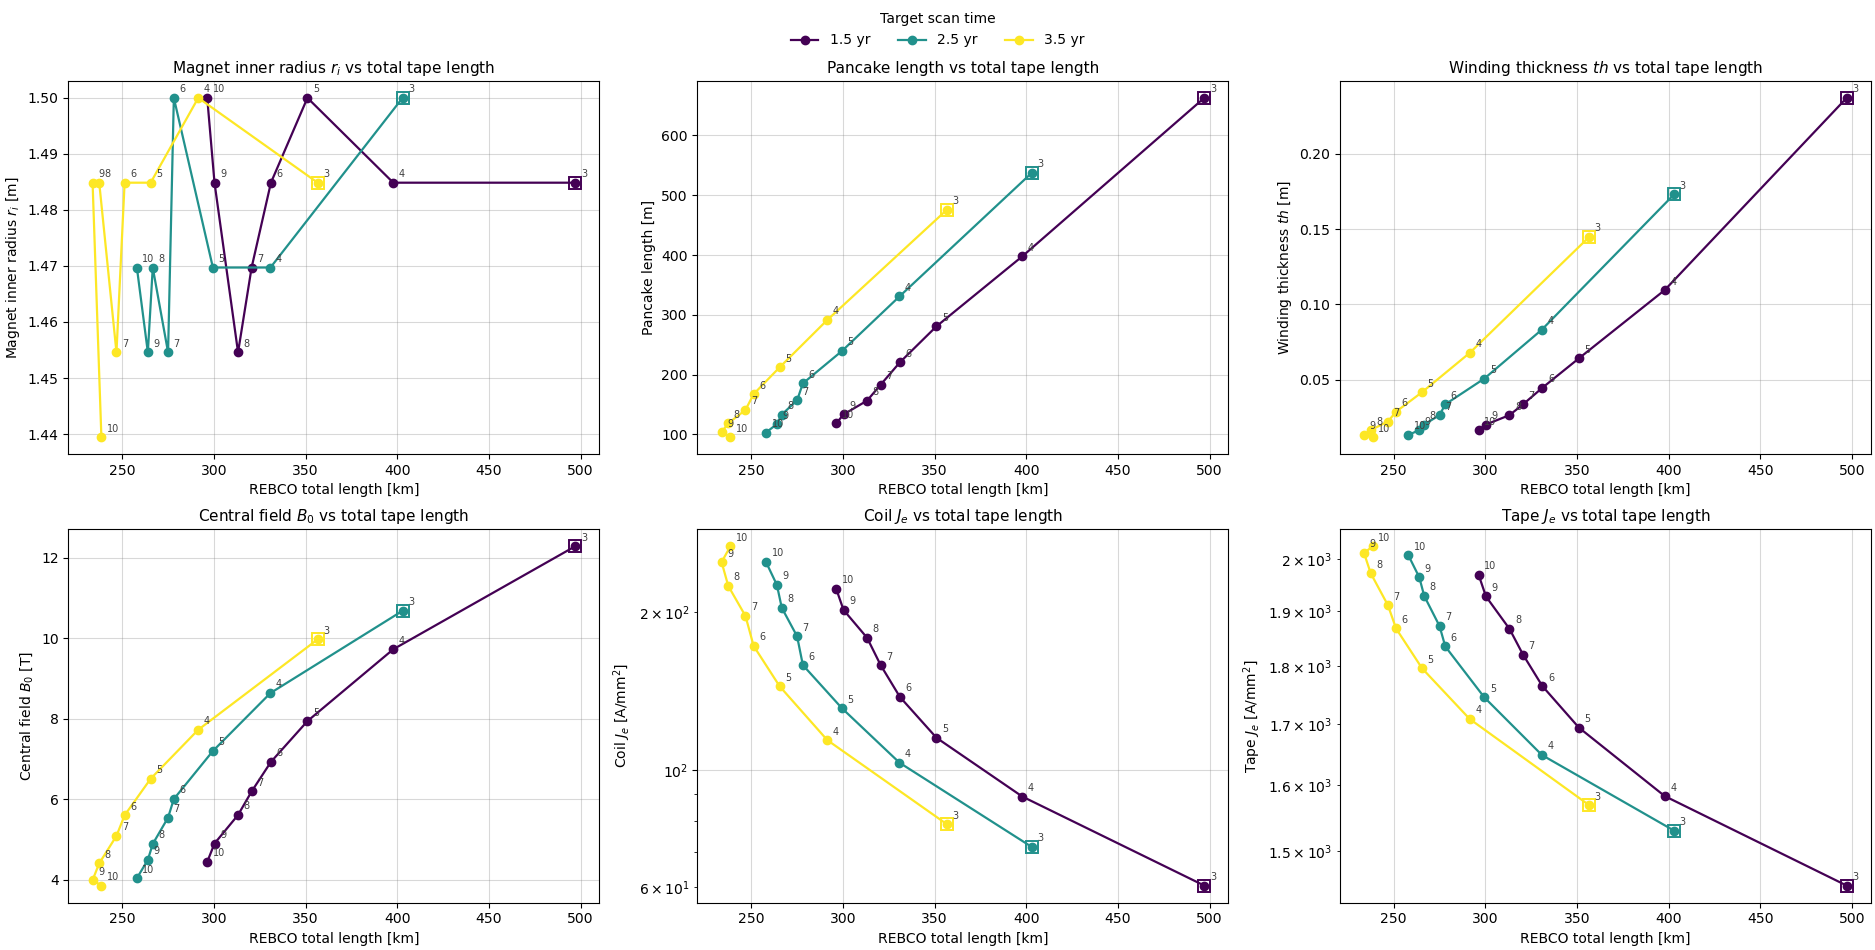

In [26]:
import math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ----------------------------- user settings --------------------------------
PATH            = 'scan_time_points.csv'
X_COL           = 'length_tape_km'          # "total length" on every x-axis
X_LABEL         = 'REBCO total length [km]' # must follow X_COL
LINE_ORDER_COL  = 'solenoid_length_m'       # connect markers in order of THIS column
MARK_LINE_START = True               # square marker on the shortest magnet
ONLY_IN_WINDOW  = True               # drop the flagged 'outside_window' fallbacks
STRICT_PANELS   = False              # True: missing panel column is fatal
ANNOTATE_LENGTH = True               # write the magnet length next to each marker
ANNOT_COLOR     = '0.25'             # dark grey; target colours are unreadable
CMAP            = plt.cm.viridis     # colour per target scan year
NCOLS           = 3
OUT             = 'scan_points_overview.png'
DPI             = 150

# (column, axis label, y-scale)
PANELS = [
    ('ri',               'Magnet inner radius $r_i$ [m]',  'linear'),
    ('pancake_length_m', 'Pancake length [m]',             'linear'),
    ('th',               'Winding thickness $th$ [m]',     'linear'),
    ('b0',               'Central field $B_0$ [T]',        'linear'),
    ('je_coil',          'Coil $J_e$ [A/mm$^2$]',          'log'),
    ('je_tape',          'Tape $J_e$ [A/mm$^2$]',          'log'),
]
# -----------------------------------------------------------------------------

PANELS = [(p + ('linear',))[:3] for p in PANELS]   # tolerate 2-tuples

df = pd.read_csv(PATH)
print(f"{PATH}: {len(df)} rows, {df.shape[1]} columns")

if X_COL not in df.columns:
    raise SystemExit(f"missing x column {X_COL!r}. Available: "
                     + ", ".join(df.columns))

missing = [c for c, _, _ in PANELS if c not in df.columns]
if missing:
    msg = f"missing panel column(s) {missing}. Available: " + ", ".join(df.columns)
    if STRICT_PANELS:
        raise SystemExit(msg)
    print("  warning: " + msg)
    PANELS = [p for p in PANELS if p[0] in df.columns]
if not PANELS:
    raise SystemExit("no panel columns present")

if ONLY_IN_WINDOW:
    if 'match_status' in df.columns:
        n0 = len(df)
        df = df[df['match_status'] == 'in_window'].copy()
        print(f"  kept {len(df)}/{n0} rows with match_status == 'in_window'")
    else:
        print("  warning: match_status absent - ONLY_IN_WINDOW applied no filtering")

if 'converged' in df.columns:
    # astype(bool) would map NaN and the string 'False' to True
    bad = df['converged'].isin([False, 'False', 'false', 'FALSE', 0, '0'])
    n_bad = int(bad.sum()) + int(df['converged'].isna().sum())
    if n_bad:
        print(f"  warning: {n_bad} selected design(s) not converged or unlabelled")
    unconverged = bad | df['converged'].isna()
else:
    unconverged = pd.Series(False, index=df.index)

if len(df) == 0:
    raise SystemExit("nothing left to plot after filtering")

has_target = 'target_scan_yrs' in df.columns
has_len    = 'solenoid_length_m' in df.columns
targets    = np.sort(df['target_scan_yrs'].unique()) if has_target else [None]

# order the connecting line by magnet length when that column exists
if LINE_ORDER_COL in df.columns:
    SORT_KEYS = [LINE_ORDER_COL, X_COL]
    print(f"  line order: increasing {LINE_ORDER_COL} (ties broken by {X_COL})")
else:
    SORT_KEYS = [X_COL]
    print(f"  warning: {LINE_ORDER_COL!r} absent - line ordered by {X_COL}")

if has_target and len(targets) > 1:
    norm = mpl.colors.Normalize(vmin=float(np.min(targets)),
                                vmax=float(np.max(targets)))
    color_of = {t: CMAP(norm(t)) for t in targets}
else:
    color_of = {t: CMAP(0.45) for t in targets}

dup = df.duplicated(subset=[X_COL] + (['solenoid_length_m'] if has_len else []),
                    keep=False)
if dup.any():
    print(f"  note: {int(dup.sum())} rows share an (x, magnet length) coordinate; "
          "markers will overlap")


def draw(ax, ycol, ylabel, yscale):
    """One panel: y-quantity vs total tape length, one line per target year.

    Markers keep their (tape length, y) position; the polyline joining them
    runs from the shortest magnet to the longest, so it may double back if the
    two lengths are not monotonically related.
    """
    drawn_any = False
    for t in targets:
        sub = (df if t is None else df[df['target_scan_yrs'] == t])
        sub = sub.sort_values(SORT_KEYS, kind='mergesort')
        # a NaN in x or y would break the line; drop those rows for the line
        sub = sub[sub[X_COL].notna() & sub[ycol].notna()]
        if len(sub) == 0:
            continue
        drawn_any = True
        ax.plot(sub[X_COL], sub[ycol], marker='o', markersize=6, linewidth=1.6,
                color=color_of[t],
                label='all points' if t is None else f'{t:g} yr', zorder=3)
        # square marks the first point of the series, i.e. the shortest magnet
        if MARK_LINE_START and len(SORT_KEYS) > 1:
            ax.plot(sub[X_COL].iloc[0], sub[ycol].iloc[0], linestyle='none',
                    marker='s', markersize=9, markerfacecolor='none',
                    markeredgecolor=color_of[t], markeredgewidth=1.4, zorder=4)
        # hollow overlay marks designs flagged not-converged
        bad = sub[unconverged.reindex(sub.index, fill_value=False)]
        if len(bad):
            ax.plot(bad[X_COL], bad[ycol], linestyle='none', marker='o',
                    markersize=9, markerfacecolor='none',
                    markeredgecolor='crimson', markeredgewidth=1.2, zorder=5)
        if ANNOTATE_LENGTH and has_len:
            for _, r in sub.iterrows():
                ax.annotate(f"{r['solenoid_length_m']:g}",
                            xy=(r[X_COL], r[ycol]), xytext=(4, 4),
                            textcoords='offset points', fontsize=7,
                            color=ANNOT_COLOR, zorder=6)

    if yscale == 'log':
        finite = df[ycol].to_numpy(dtype=float)
        finite = finite[np.isfinite(finite)]
        if finite.size and (finite > 0).all():
            ax.set_yscale('log')
        else:
            print(f"  note: {ycol} has non-positive values; keeping linear y-axis")

    ax.set_xlabel(X_LABEL)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title(f"{ylabel.split(' [')[0]} vs total tape length", fontsize=11)
    if not drawn_any:
        ax.text(0.5, 0.5, f"no finite {ycol}", transform=ax.transAxes,
                ha='center', va='center', fontsize=9, color='0.4')


nrows = math.ceil(len(PANELS) / NCOLS)
fig, axes = plt.subplots(nrows, NCOLS,
                         figsize=(6.25 * NCOLS, 4.75 * nrows),
                         constrained_layout=True, squeeze=False)
flat = axes.ravel()
for ax, (ycol, ylabel, yscale) in zip(flat, PANELS):
    draw(ax, ycol, ylabel, yscale)
for ax in flat[len(PANELS):]:
    fig.delaxes(ax)

handles, labels = flat[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels,
               title='Target scan time' if has_target else None,
               loc='outside upper center', ncol=min(len(labels), 6),
               frameon=False)


fig.savefig(OUT, dpi=DPI, bbox_inches='tight')

plt.show()

In [ ]:
import importlib
import math
import solenoid_lib


importlib.reload(solenoid_lib)


from solenoid_lib import scan_time, dB_to_eta

# Magnet / bore geometry
B0_baseline = 18          # T
l_bore      = 8.5         # m
d_bore      = 0.090       # m
V_m3        = math.pi * (d_bore / 2)**2 * l_bore   # bore volume [m^3]
print(f"Bore volume: {V_m3:.4f} m^3")

s_per_year = 365.25 * 24 * 3600


print(f"{'Scenario':<40} {'Expected':>10}  {'DFSZ':>10} {'Ratio':>10}")
print("-" * 74)

scenarios = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q'),
    (B0_baseline, V_m3, 20e6, -20, 2.24,  'CORE-GUT')
]

for (B0, V_m3, Q, eta_dB, expected, name) in scenarios:
    eta_A  = dB_to_eta(eta_dB)
    t_dfsz = scan_time(B0, V_m3, Q=Q, eta_A=eta_A, model='DFSZ')
    ratio  = expected / t_dfsz
    print(f"{name:<40} {expected:>10.1f} {t_dfsz:>10.2f} {ratio:>10.3f}")